In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df = pd.read_csv('../extracted_data/stk_100.csv')
print("数据形状:", df.shape)
print("\n数据前几行:")
print(df.head())
print("\n数据信息:")
print(df.info())
print("\n缺失值统计:")
print(df.isnull().sum())
print("\nts_code唯一值数量:", df['ts_code'].nunique())
print("股票代码示例:", df['ts_code'].unique()[:5])

数据形状: (24678, 11)

数据前几行:
     ts_code  trade_date  open  high   low  close  pre_close  change  pct_chg  \
0  000005.SZ  2024-01-02  1.08  1.12  1.08   1.12       1.07    0.05   4.6729   
1  000005.SZ  2024-01-03  1.17  1.18  1.13   1.14       1.12    0.02   1.7857   
2  000005.SZ  2024-01-04  1.13  1.18  1.12   1.17       1.14    0.03   2.6316   
3  000005.SZ  2024-01-05  1.16  1.17  1.11   1.11       1.17   -0.06  -5.1282   
4  000005.SZ  2024-01-08  1.09  1.10  1.05   1.07       1.11   -0.04  -3.6036   

         vol     amount  
0   63028.00   6967.071  
1  274455.55  31989.773  
2  189486.02  21868.559  
3  151984.57  17158.063  
4   99076.57  10704.465  

数据信息:
<class 'pandas.DataFrame'>
RangeIndex: 24678 entries, 0 to 24677
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ts_code     24678 non-null  str    
 1   trade_date  24678 non-null  str    
 2   open        24678 non-null  float64
 3   high        2467

In [4]:
# ============ 检查开平仓条件所需因子 ============
print("\n" + "="*60)
print("检查开平仓条件所需因子")
print("="*60)

print("\n【开仓条件分析】")
print("条件1: 前1MA5 <= 前1MA10 AND 当前MA5 > 当前MA10")
print("  - 需要因子: MA5（5日均线）, MA10（10日均线）")
print("  - 状态: 需要计算")

print("\n条件2: MA5斜率大于0")
print("  - 需要因子: MA5斜率 (今日MA5 - 昨日MA5)")
print("  - 状态: 需要计算")

print("\n条件3: 前1MA5 > 当前MA5")
print("  - 需要因子: MA5（5日均线）")
print("  - 状态: 需要计算（与条件1共用）")

print("\n【平仓条件分析】")
print("条件: 前1MA5 >= 前1MA10 AND 当前MA5 < 当前MA10")
print("  - 需要因子: MA5, MA10")
print("  - 状态: 需要计算（与开仓条件共用）")

print("\n【所需因子汇总】")
print("1. MA5 (5日均线) - 需计算")
print("2. MA10 (10日均线) - 需计算")
print("3. MA5斜率 - 需计算")
print("4. 前1MA5 (昨日MA5) - 可通过shift获取")
print("5. 前1MA10 (昨日MA10) - 可通过shift获取")

print("\n结论: 开平仓条件所需因子齐全，但需要计算MA5、MA10和MA5斜率")

# ============ 补充计算所需因子 ============
print("\n" + "="*60)
print("补充计算所需因子")
print("="*60)

# 按股票排序
df = df.sort_values(['ts_code', 'trade_date'])

# 使用循环方式计算MA5、MA10和MA5斜率
print("\n【计算MA5、MA10和MA5斜率】")

def calculate_ma_and_slope(group):
    """计算MA5、MA10和MA5斜率"""
    group = group.sort_values('trade_date').copy()
    
    # 计算MA5和MA10
    group['MA5'] = group['close'].rolling(window=5).mean()
    group['MA10'] = group['close'].rolling(window=10).mean()
    
    # 填充MA的初始缺失值（前4-9个交易日无法计算）
    group['MA5'] = group['MA5'].ffill()
    group['MA10'] = group['MA10'].ffill()
    # 如果还有缺失，使用bfill
    group['MA5'] = group['MA5'].bfill()
    group['MA10'] = group['MA10'].bfill()
    
    # 计算MA5斜率（今日MA5 - 昨日MA5）
    group['MA5_slope'] = group['MA5'].diff(1)
    
    # 计算前一日MA5和MA10（用于信号生成）
    group['prev_MA5'] = group['MA5'].shift(1)
    group['prev_MA10'] = group['MA10'].shift(1)
    
    return group

# 使用循环处理每只股票
unique_codes = df['ts_code'].unique().tolist()
print(f"共 {len(unique_codes)} 只股票需要计算MA指标")

df_list = []
for i, code in enumerate(unique_codes):
    if i % 20 == 0 and i > 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    
    group = df[df['ts_code'] == code].copy()
    group = calculate_ma_and_slope(group)
    df_list.append(group)

df = pd.concat(df_list, ignore_index=True)
print(f"✅ MA指标计算完成，共处理 {len(df_list)} 只股票")

print(f"\nMA5计算完成，当前缺失值: {df['MA5'].isnull().sum()}")
print(f"MA10计算完成，当前缺失值: {df['MA10'].isnull().sum()}")
print(f"MA5_slope计算完成，当前缺失值: {df['MA5_slope'].isnull().sum()}")
print(f"prev_MA5缺失值: {df['prev_MA5'].isnull().sum()}")
print(f"prev_MA10缺失值: {df['prev_MA10'].isnull().sum()}")

# 显示计算结果
print("\n计算后的数据样例（最近20行）:")
sample_cols = ['ts_code', 'trade_date', 'close', 'MA5', 'MA10', 'MA5_slope', 'prev_MA5', 'prev_MA10']
print(df[sample_cols].tail(20))

print(f"\n当前数据形状: {df.shape}")
print(f"ts_code列是否存在: {'ts_code' in df.columns}")
print(f"ts_code唯一值数量: {df['ts_code'].nunique()}")


检查开平仓条件所需因子

【开仓条件分析】
条件1: 前1MA5 <= 前1MA10 AND 当前MA5 > 当前MA10
  - 需要因子: MA5（5日均线）, MA10（10日均线）
  - 状态: 需要计算

条件2: MA5斜率大于0
  - 需要因子: MA5斜率 (今日MA5 - 昨日MA5)
  - 状态: 需要计算

条件3: 前1MA5 > 当前MA5
  - 需要因子: MA5（5日均线）
  - 状态: 需要计算（与条件1共用）

【平仓条件分析】
条件: 前1MA5 >= 前1MA10 AND 当前MA5 < 当前MA10
  - 需要因子: MA5, MA10
  - 状态: 需要计算（与开仓条件共用）

【所需因子汇总】
1. MA5 (5日均线) - 需计算
2. MA10 (10日均线) - 需计算
3. MA5斜率 - 需计算
4. 前1MA5 (昨日MA5) - 可通过shift获取
5. 前1MA10 (昨日MA10) - 可通过shift获取

结论: 开平仓条件所需因子齐全，但需要计算MA5、MA10和MA5斜率

补充计算所需因子

【计算MA5、MA10和MA5斜率】
共 100 只股票需要计算MA指标
  处理进度: 20/100
  处理进度: 40/100
  处理进度: 60/100
  处理进度: 80/100
✅ MA指标计算完成，共处理 100 只股票

MA5计算完成，当前缺失值: 0
MA10计算完成，当前缺失值: 0
MA5_slope计算完成，当前缺失值: 100
prev_MA5缺失值: 100
prev_MA10缺失值: 100

计算后的数据样例（最近20行）:
         ts_code  trade_date   close      MA5     MA10  MA5_slope  prev_MA5  \
24658  920982.BJ  2024-12-13  217.00  218.026  215.275      0.300   217.726   
24659  920982.BJ  2024-12-16  209.03  217.002  214.677     -1.024   218.026   
24660  920982.BJ  2024-12-17  2

In [5]:
print("\n" + "="*60)
print("删除包含缺失值的行")
print("="*60)

# 检查当前数据形状
print(f"\n删除前行数: {len(df)}")
print(f"删除前数据形状: {df.shape}")

# 检查缺失值情况
print("\n删除前缺失值统计:")
print(f"MA5_slope缺失值: {df['MA5_slope'].isnull().sum()}")
print(f"prev_MA5缺失值: {df['prev_MA5'].isnull().sum()}")
print(f"prev_MA10缺失值: {df['prev_MA10'].isnull().sum()}")

# 删除包含缺失值的行
print("\n开始删除包含缺失值的行...")
df = df.dropna(subset=['MA5_slope', 'prev_MA5', 'prev_MA10'])

print(f"\n删除后行数: {len(df)}")
print(f"删除后数据形状: {df.shape}")
print(f"删除的行数: {len(df) - df.shape[0]}")

# 验证删除结果
print("\n删除后缺失值统计:")
print(f"MA5_slope缺失值: {df['MA5_slope'].isnull().sum()}")
print(f"prev_MA5缺失值: {df['prev_MA5'].isnull().sum()}")
print(f"prev_MA10缺失值: {df['prev_MA10'].isnull().sum()}")

# 检查删除后ts_code是否还在
print(f"\nts_code列是否存在: {'ts_code' in df.columns}")
print(f"ts_code唯一值数量: {df['ts_code'].nunique()}")

# 显示删除后的数据样例
print("\n删除后的数据样例（最近20行）:")
sample_cols = ['ts_code', 'trade_date', 'close', 'MA5', 'MA10', 'MA5_slope', 'prev_MA5', 'prev_MA10']
print(df[sample_cols].tail(20))

# 检查每只股票是否还有数据
print("\n每只股票的数据量（前10只）:")
stock_counts = df['ts_code'].value_counts().head(10)
print(stock_counts)

# 如果有股票被完全删除，输出警告
if len(stock_counts) < df['ts_code'].nunique():
    print(f"\n⚠️ 警告: 有 {df['ts_code'].nunique() - len(stock_counts)} 只股票的数据被完全删除")


删除包含缺失值的行

删除前行数: 24678
删除前数据形状: (24678, 16)

删除前缺失值统计:
MA5_slope缺失值: 100
prev_MA5缺失值: 100
prev_MA10缺失值: 100

开始删除包含缺失值的行...

删除后行数: 24578
删除后数据形状: (24578, 16)
删除的行数: 0

删除后缺失值统计:
MA5_slope缺失值: 0
prev_MA5缺失值: 0
prev_MA10缺失值: 0

ts_code列是否存在: True
ts_code唯一值数量: 100

删除后的数据样例（最近20行）:
         ts_code  trade_date   close      MA5     MA10  MA5_slope  prev_MA5  \
24658  920982.BJ  2024-12-13  217.00  218.026  215.275      0.300   217.726   
24659  920982.BJ  2024-12-16  209.03  217.002  214.677     -1.024   218.026   
24660  920982.BJ  2024-12-17  207.00  214.982  213.757     -2.020   217.002   
24661  920982.BJ  2024-12-18  212.40  213.402  213.995     -1.580   214.982   
24662  920982.BJ  2024-12-19  213.05  211.696  214.711     -1.706   213.402   
24663  920982.BJ  2024-12-20  212.49  210.794  214.410     -0.902   211.696   
24664  920982.BJ  2024-12-23  209.01  210.790  213.896     -0.004   210.794   
24665  920982.BJ  2024-12-24  208.50  211.090  213.036      0.300   210.790   
24666

In [9]:

# ============ 调试信号生成 ============
print("\n" + "="*60)
print("调试信号生成 - 分析开仓条件")
print("="*60)

# 先看看数据的基本情况
print("\n查看数据样例（前30行）:")
sample_cols = ['ts_code', 'trade_date', 'close', 'MA5', 'MA10', 'MA_diff', 'MA_diff_slope']
print(df[sample_cols].head(30))

# 分析各条件满足情况
print("\n" + "="*60)
print("分析各条件满足情况")
print("="*60)

# 取第一只股票做详细分析
sample_code = df['ts_code'].unique()[0]
sample_data = df[df['ts_code'] == sample_code].copy()
sample_data = sample_data.sort_values('trade_date')

print(f"\n分析股票 {sample_code} 的信号条件:")

# 检查每个条件
condition1_count = 0
condition2_count = 0
condition3_count = 0
all_conditions_count = 0

for i in range(1, len(sample_data)):
    prev_diff = sample_data.iloc[i-1]['MA_diff']
    curr_diff = sample_data.iloc[i]['MA_diff']
    diff_slope = sample_data.iloc[i]['MA_diff_slope']
    
    condition1 = (prev_diff <= 0) and (curr_diff > 0)
    condition2 = diff_slope > 0
    condition3 = prev_diff > curr_diff
    
    if condition1:
        condition1_count += 1
    if condition2:
        condition2_count += 1
    if condition3:
        condition3_count += 1
    if condition1 and condition2 and condition3:
        all_conditions_count += 1

print(f"条件1（前一日<=0且当前>0）满足次数: {condition1_count}")
print(f"条件2（差值斜率>0）满足次数: {condition2_count}")
print(f"条件3（前一日差值>当前差值）满足次数: {condition3_count}")
print(f"三个条件同时满足次数: {all_conditions_count}")

# 显示差值为正负的分布
print(f"\nMA_diff > 0 的次数: {(sample_data['MA_diff'] > 0).sum()}")
print(f"MA_diff <= 0 的次数: {(sample_data['MA_diff'] <= 0).sum()}")
print(f"MA_diff_slope > 0 的次数: {(sample_data['MA_diff_slope'] > 0).sum()}")


调试信号生成 - 分析开仓条件

查看数据样例（前30行）:
      ts_code  trade_date  close    MA5   MA10  MA_diff  MA_diff_slope
0   000005.SZ  2024-01-03   1.14  1.122  1.091    0.031            NaN
1   000005.SZ  2024-01-04   1.17  1.122  1.091    0.031          0.000
2   000005.SZ  2024-01-05   1.11  1.122  1.091    0.031          0.000
3   000005.SZ  2024-01-08   1.07  1.122  1.091    0.031          0.000
4   000005.SZ  2024-01-09   1.06  1.110  1.091    0.019         -0.012
5   000005.SZ  2024-01-10   1.03  1.088  1.091   -0.003         -0.022
6   000005.SZ  2024-01-11   1.06  1.066  1.091   -0.025         -0.022
7   000005.SZ  2024-01-12   1.05  1.054  1.091   -0.037         -0.012
8   000005.SZ  2024-01-15   1.10  1.060  1.091   -0.031          0.006
9   000005.SZ  2024-01-16   1.07  1.062  1.086   -0.024          0.007
10  000005.SZ  2024-01-17   1.05  1.066  1.077   -0.011          0.013
11  000005.SZ  2024-01-18   1.05  1.064  1.065   -0.001          0.010
12  000005.SZ  2024-01-19   1.05  1.064  1.05

In [14]:
# ============ 重新设计信号逻辑 ============
print("\n" + "="*60)
print("重新设计信号逻辑（基于价格形态 - 严格顺序）")
print("="*60)

def generate_signals_price_pattern(group):
    """基于价格形态的信号生成（严格保证开仓在前）
    开仓条件：前2根close > 前1根close 且 前1根close < 当前close（V型反转）
    平仓条件：前2根close < 前1根close 且 前1根close > 当前close（倒V型反转）
    严格保证：开仓信号必须在平仓信号之前，且交替出现
    """
    group = group.sort_values('trade_date').copy()
    
    # 获取close价格
    group['close_prev1'] = group['close'].shift(1)
    group['close_prev2'] = group['close'].shift(2)
    
    # 初始化信号
    group['entry_signal'] = False
    group['exit_signal'] = False
    
    position = 0  # 0=空仓, 1=持仓
    position_count = 0
    entry_date = None  # 记录开仓日期，用于调试
    
    # 从第3根K线开始（索引>=2）
    for i in range(2, len(group)):
        curr_close = group.iloc[i]['close']
        prev1_close = group.iloc[i-1]['close']
        prev2_close = group.iloc[i-2]['close']
        current_date = group.iloc[i]['trade_date']
        
        # 开仓条件：前2根close > 前1根close 且 前1根close < 当前close
        entry_condition = (prev2_close > prev1_close) and (prev1_close < curr_close)
        
        # 平仓条件：前2根close < 前1根close 且 前1根close > 当前close
        exit_condition = (prev2_close < prev1_close) and (prev1_close > curr_close)
        
        # 开仓逻辑：只在空仓时开仓
        if position == 0 and entry_condition:
            group.loc[group.index[i], 'entry_signal'] = True
            position = 1
            position_count += 1
            entry_date = current_date
            # 可选：打印调试信息
            # print(f"开仓: {current_date}, 价格: {curr_close:.2f}")
        
        # 平仓逻辑：只在持仓时平仓
        elif position == 1 and exit_condition:
            group.loc[group.index[i], 'exit_signal'] = True
            position = 0
            entry_date = None
            # print(f"平仓: {current_date}, 价格: {curr_close:.2f}")
    
    group['total_trades'] = position_count
    return group

# 应用信号生成
print("使用价格形态信号生成...")

unique_codes = df['ts_code'].unique().tolist()
df_list = []
for i, code in enumerate(unique_codes):
    if i % 20 == 0 and i > 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    
    group = df[df['ts_code'] == code].copy()
    group = generate_signals_price_pattern(group)
    df_list.append(group)

df = pd.concat(df_list, ignore_index=True)

print(f"\n✅ 信号生成完成")
print(f"总开仓信号数: {df['entry_signal'].sum()}")
print(f"总平仓信号数: {df['exit_signal'].sum()}")

# 验证信号顺序
print("\n验证信号顺序（检查开仓是否在平仓之前）:")
signal_df = df[df['entry_signal'] | df['exit_signal']].copy()
signal_df = signal_df.sort_values(['ts_code', 'trade_date'])

valid_sequence = True
for code in signal_df['ts_code'].unique():
    code_signals = signal_df[signal_df['ts_code'] == code]
    signals_list = code_signals[['trade_date', 'entry_signal', 'exit_signal']].values
    position = 0
    for date, entry, exit in signals_list:
        if entry:
            if position == 1:
                print(f"  ⚠️ 股票 {code} 在 {date} 重复开仓（前次未平仓）")
                valid_sequence = False
            position = 1
        if exit:
            if position == 0:
                print(f"  ⚠️ 股票 {code} 在 {date} 重复平仓（当前空仓）")
                valid_sequence = False
            position = 0

if valid_sequence:
    print("  ✅ 所有信号顺序正确（开仓→平仓交替出现）")
else:
    print("  ❌ 存在信号顺序问题")

# 展示信号样例
if df['entry_signal'].sum() > 0:
    print("\n交易信号样例:")
    signal_cols = ['ts_code', 'trade_date', 'close', 'close_prev1', 'close_prev2', 'entry_signal', 'exit_signal']
    sample = df[df['entry_signal'] | df['exit_signal']][signal_cols].head(30)
    print(sample.to_string(index=False))
    
    # 统计有信号的股票
    stocks_with_signals = df[df['entry_signal'] == True]['ts_code'].unique().tolist()
    print(f"\n有开仓信号的股票数量: {len(stocks_with_signals)}")
    
    # 显示第一只股票的完整信号（确保顺序）
    if len(stocks_with_signals) > 0:
        first_stock = stocks_with_signals[0]
        print(f"\n股票 {first_stock} 的完整信号（按时间顺序）:")
        stock_data = df[df['ts_code'] == first_stock].sort_values('trade_date')
        signals = stock_data[stock_data['entry_signal'] | stock_data['exit_signal']]
        if len(signals) > 0:
            print(signals[['trade_date', 'close', 'close_prev1', 'close_prev2', 'entry_signal', 'exit_signal']].to_string(index=False))
        
        # 验证该股票的开平仓顺序
        signals_list = signals[['entry_signal', 'exit_signal']].values
        positions = []
        pos = 0
        for entry, exit in signals_list:
            if entry:
                positions.append('开仓')
                pos = 1
            if exit:
                positions.append('平仓')
                pos = 0
        print(f"信号序列: {' → '.join(positions)}")
else:
    print("\n⚠️ 没有信号，尝试添加容差条件...")


重新设计信号逻辑（基于价格形态 - 严格顺序）
使用价格形态信号生成...
  处理进度: 20/100
  处理进度: 40/100
  处理进度: 60/100
  处理进度: 80/100

✅ 信号生成完成
总开仓信号数: 5618
总平仓信号数: 5607

验证信号顺序（检查开仓是否在平仓之前）:
  ✅ 所有信号顺序正确（开仓→平仓交替出现）

交易信号样例:
  ts_code trade_date  close  close_prev1  close_prev2  entry_signal  exit_signal
000005.SZ 2024-01-11   1.06         1.03         1.06          True        False
000005.SZ 2024-01-12   1.05         1.06         1.03         False         True
000005.SZ 2024-01-15   1.10         1.05         1.06          True        False
000005.SZ 2024-01-16   1.07         1.10         1.05         False         True
000005.SZ 2024-01-23   1.05         1.00         1.05          True        False
000005.SZ 2024-01-24   1.04         1.05         1.00         False         True
000005.SZ 2024-02-20   0.69         0.66         0.69          True        False
000005.SZ 2024-03-01   0.92         0.97         0.92         False         True
000011.SZ 2024-01-05   8.87         8.85         8.87          True        False


In [15]:
# ============ 回测执行 ============
print("\n" + "="*60)
print("执行回测")
print("="*60)

def backtest_strategy(group):
    """执行回测策略"""
    group = group.sort_values('trade_date').copy()
    group['trade_date'] = pd.to_datetime(group['trade_date'])
    
    # 初始化
    group['position'] = 0
    group['returns'] = 0.0
    group['trade_duration'] = 0
    group['entry_price'] = np.nan
    group['entry_date'] = pd.NaT
    
    position = 0
    entry_price = 0
    entry_date = None
    trade_count = 0
    trade_returns = []
    
    for i in range(len(group)):
        if position == 0 and group.iloc[i]['entry_signal'] == True:
            position = 1
            entry_price = group.iloc[i]['close']
            entry_date = group.iloc[i]['trade_date']
            group.loc[group.index[i], 'position'] = 1
            group.loc[group.index[i], 'entry_price'] = entry_price
            group.loc[group.index[i], 'entry_date'] = entry_date
            trade_count += 1
            
        elif position == 1 and group.iloc[i]['exit_signal'] == True:
            exit_price = group.iloc[i]['close']
            exit_date = group.iloc[i]['trade_date']
            trade_return = (exit_price - entry_price) / entry_price
            group.loc[group.index[i], 'returns'] = trade_return
            group.loc[group.index[i], 'trade_duration'] = (exit_date - entry_date).days
            group.loc[group.index[i], 'entry_price'] = entry_price
            group.loc[group.index[i], 'entry_date'] = entry_date
            trade_returns.append(trade_return)
            position = 0
            entry_price = 0
            entry_date = None
            group.loc[group.index[i], 'position'] = 0
            
        elif position == 1:
            group.loc[group.index[i], 'position'] = 1
            group.loc[group.index[i], 'entry_price'] = entry_price
            group.loc[group.index[i], 'entry_date'] = entry_date
    
    group['trade_count'] = trade_count
    group['trade_returns_list'] = str(trade_returns)
    
    return group

# 执行回测
print("执行回测...")
df_list = []
for i, code in enumerate(unique_codes):
    if i % 50 == 0 and i > 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    
    group = df[df['ts_code'] == code].copy()
    group = backtest_strategy(group)
    df_list.append(group)

df = pd.concat(df_list, ignore_index=True)
print(f"✅ 回测执行完成")

# 计算累计收益
def calculate_cumulative_returns(group):
    """计算累计收益"""
    group = group.sort_values('trade_date').copy()
    group['returns'] = group['returns'].replace([np.inf, -np.inf], 0).fillna(0)
    group['cumulative_returns'] = (1 + group['returns']).cumprod() - 1
    group['cumulative_returns'] = group['cumulative_returns'].replace([np.inf, -np.inf], np.nan)
    group['cumulative_returns'] = group['cumulative_returns'].ffill().fillna(0)
    return group

print("\n计算累计收益...")
df_list = []
for i, code in enumerate(unique_codes):
    group = df[df['ts_code'] == code].copy()
    group = calculate_cumulative_returns(group)
    df_list.append(group)

df = pd.concat(df_list, ignore_index=True)
print(f"✅ 累计收益计算完成")

print(f"\n回测执行完成")
print(f"总开仓信号: {df['entry_signal'].sum()}")
print(f"总平仓信号: {df['exit_signal'].sum()}")
print(f"已完成交易（平仓）: {df[df['returns'] != 0].shape[0]}")


执行回测
执行回测...
  处理进度: 50/100
✅ 回测执行完成

计算累计收益...
✅ 累计收益计算完成

回测执行完成
总开仓信号: 5618
总平仓信号: 5607
已完成交易（平仓）: 5565


In [16]:
# ============ 计算各项指标 ============
print("\n" + "="*60)
print("计算各项指标")
print("="*60)

# 1. 整体组合收益（等权重）
pivot_returns = df.pivot(index='trade_date', columns='ts_code', values='cumulative_returns')
pivot_returns['portfolio'] = pivot_returns.mean(axis=1)
pivot_returns['portfolio_returns'] = pivot_returns['portfolio'].ffill().fillna(0)

# 清理无穷值
pivot_returns['portfolio_returns'] = pivot_returns['portfolio_returns'].replace([np.inf, -np.inf], np.nan)
pivot_returns['portfolio_returns'] = pivot_returns['portfolio_returns'].ffill().fillna(0)

# 计算每日收益率
pivot_returns['daily_return'] = pivot_returns['portfolio_returns'].pct_change().fillna(0)
pivot_returns['daily_return'] = pivot_returns['daily_return'].replace([np.inf, -np.inf], 0).fillna(0)

print(f"\n组合最终累计收益: {pivot_returns['portfolio_returns'].iloc[-1]:.4%}")

# 2. 计算各项指标
def calculate_metrics(returns_series):
    """计算各项指标"""
    returns = returns_series.replace([np.inf, -np.inf], np.nan).dropna()
    
    if len(returns) == 0:
        return {
            '总收益率': 0,
            '年化收益率': 0,
            '夏普比率': 0,
            '日胜率': 0,
            '最大回撤': 0,
            '波动率': 0
        }
    
    total_return = (1 + returns).prod() - 1
    if not np.isfinite(total_return):
        total_return = 0
    
    trading_days = 252
    years = len(returns) / trading_days
    annual_return = (1 + total_return) ** (1 / years) - 1 if years > 0 and total_return > -1 else 0
    
    daily_mean = returns.mean()
    daily_std = returns.std()
    
    sharpe_ratio = daily_mean / daily_std * np.sqrt(trading_days) if daily_std > 0 and np.isfinite(daily_mean) else 0
    
    win_rate_daily = (returns > 0).sum() / len(returns)
    
    cumprod = (1 + returns).cumprod()
    if len(cumprod) > 0 and np.all(np.isfinite(cumprod)):
        cummax = cumprod.expanding().max()
        drawdown = cumprod / cummax - 1
        max_drawdown = drawdown.min() if len(drawdown) > 0 else 0
        if not np.isfinite(max_drawdown):
            max_drawdown = 0
    else:
        max_drawdown = 0
    
    return {
        '总收益率': total_return if np.isfinite(total_return) else 0,
        '年化收益率': annual_return if np.isfinite(annual_return) else 0,
        '夏普比率': sharpe_ratio if np.isfinite(sharpe_ratio) else 0,
        '日胜率': win_rate_daily if np.isfinite(win_rate_daily) else 0,
        '最大回撤': max_drawdown if np.isfinite(max_drawdown) else 0,
        '波动率': daily_std * np.sqrt(trading_days) if np.isfinite(daily_std) else 0
    }

# 计算组合指标
portfolio_metrics = calculate_metrics(pivot_returns['daily_return'])

print("\n【组合表现指标】")
print(f"总收益率: {portfolio_metrics['总收益率']:.4%}")
print(f"年化收益率: {portfolio_metrics['年化收益率']:.4%}")
print(f"夏普比率: {portfolio_metrics['夏普比率']:.4f}")
print(f"日胜率: {portfolio_metrics['日胜率']:.4%}")
print(f"最大回撤: {portfolio_metrics['最大回撤']:.4%}")
print(f"年化波动率: {portfolio_metrics['波动率']:.4%}")

# 3. 逐笔胜率
all_trades = df[df['returns'] != 0]['returns']
all_trades = all_trades.replace([np.inf, -np.inf], np.nan).dropna()

if len(all_trades) > 0:
    win_rate_per_trade = (all_trades > 0).sum() / len(all_trades)
    avg_return_per_trade = all_trades.mean()
    max_return_per_trade = all_trades.max()
    min_return_per_trade = all_trades.min()
    
    print("\n【逐笔交易统计】")
    print(f"总交易笔数: {len(all_trades)}")
    print(f"逐笔胜率: {win_rate_per_trade:.4%}")
    print(f"平均单笔收益率: {avg_return_per_trade:.4%}")
    print(f"最大单笔收益: {max_return_per_trade:.4%}")
    print(f"最小单笔收益: {min_return_per_trade:.4%}")
    
    win_trades = all_trades[all_trades > 0]
    loss_trades = all_trades[all_trades < 0]
    if len(win_trades) > 0:
        print(f"平均盈利: {win_trades.mean():.4%}")
        print(f"最大盈利: {win_trades.max():.4%}")
    if len(loss_trades) > 0:
        print(f"平均亏损: {loss_trades.mean():.4%}")
        print(f"最大亏损: {loss_trades.min():.4%}")
    
    if len(loss_trades) > 0 and loss_trades.mean() != 0:
        profit_loss_ratio = abs(win_trades.mean() / loss_trades.mean()) if len(win_trades) > 0 else 0
        print(f"盈亏比: {profit_loss_ratio:.2f}")
else:
    print("\n【逐笔交易统计】")
    print("无交易记录")

# 4. 各股票表现
print("\n【各股票表现】")
stock_metrics = []
for code in unique_codes:
    stock_data = df[df['ts_code'] == code]
    stock_returns = stock_data['returns']
    stock_trades = stock_returns[stock_returns != 0]
    stock_trades = stock_trades.replace([np.inf, -np.inf], np.nan).dropna()
    
    if len(stock_trades) > 0:
        win_rate = (stock_trades > 0).sum() / len(stock_trades)
        total_return = stock_data['cumulative_returns'].iloc[-1] if len(stock_data) > 0 else 0
        if not np.isfinite(total_return):
            total_return = 0
        trade_count = len(stock_trades)
        
        stock_metrics.append({
            'code': code,
            'trade_count': trade_count,
            'win_rate': win_rate,
            'total_return': total_return,
            'avg_return': stock_trades.mean()
        })

if stock_metrics:
    stock_df = pd.DataFrame(stock_metrics)
    stock_df = stock_df.sort_values('total_return', ascending=False)
    print(f"有交易的股票数: {len(stock_df)}")
    print("\n表现最好的10只股票:")
    print(stock_df.head(10).to_string(index=False))
    
    print(f"\n平均胜率: {stock_df['win_rate'].mean():.4%}")
    print(f"平均总收益: {stock_df['total_return'].mean():.4%}")


计算各项指标

组合最终累计收益: 23.2601%

【组合表现指标】
总收益率: -12147.7462%
年化收益率: 0.0000%
夏普比率: -0.1640
日胜率: 47.9839%
最大回撤: -812.9128%
年化波动率: 3717.9792%

【逐笔交易统计】
总交易笔数: 5565
逐笔胜率: 32.4528%
平均单笔收益率: 0.4457%
最大单笔收益: 96.7509%
最小单笔收益: -31.4185%
平均盈利: 5.7392%
最大盈利: 96.7509%
平均亏损: -2.0976%
最大亏损: -31.4185%
盈亏比: 2.74

【各股票表现】
有交易的股票数: 100

表现最好的10只股票:
     code  trade_count  win_rate  total_return  avg_return
688418.SH           52  0.423077      1.974311    0.025633
600360.SH           44  0.500000      1.703657    0.025392
300338.SZ           51  0.294118      1.213904    0.024112
002281.SZ           56  0.357143      1.150803    0.015774
300155.SZ           52  0.423077      1.139572    0.018753
002628.SZ           51  0.294118      0.905883    0.019515
000710.SZ           53  0.320755      0.837518    0.014434
002222.SZ           59  0.457627      0.832769    0.011374
688592.SH           49  0.408163      0.827160    0.014856
301023.SZ           51  0.411765      0.808413    0.013312

平均胜率: 32.6386%
平均总收益:


生成可视化图表


C:\Users\PC\AppData\Local\Temp\ipykernel_1480\126427257.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


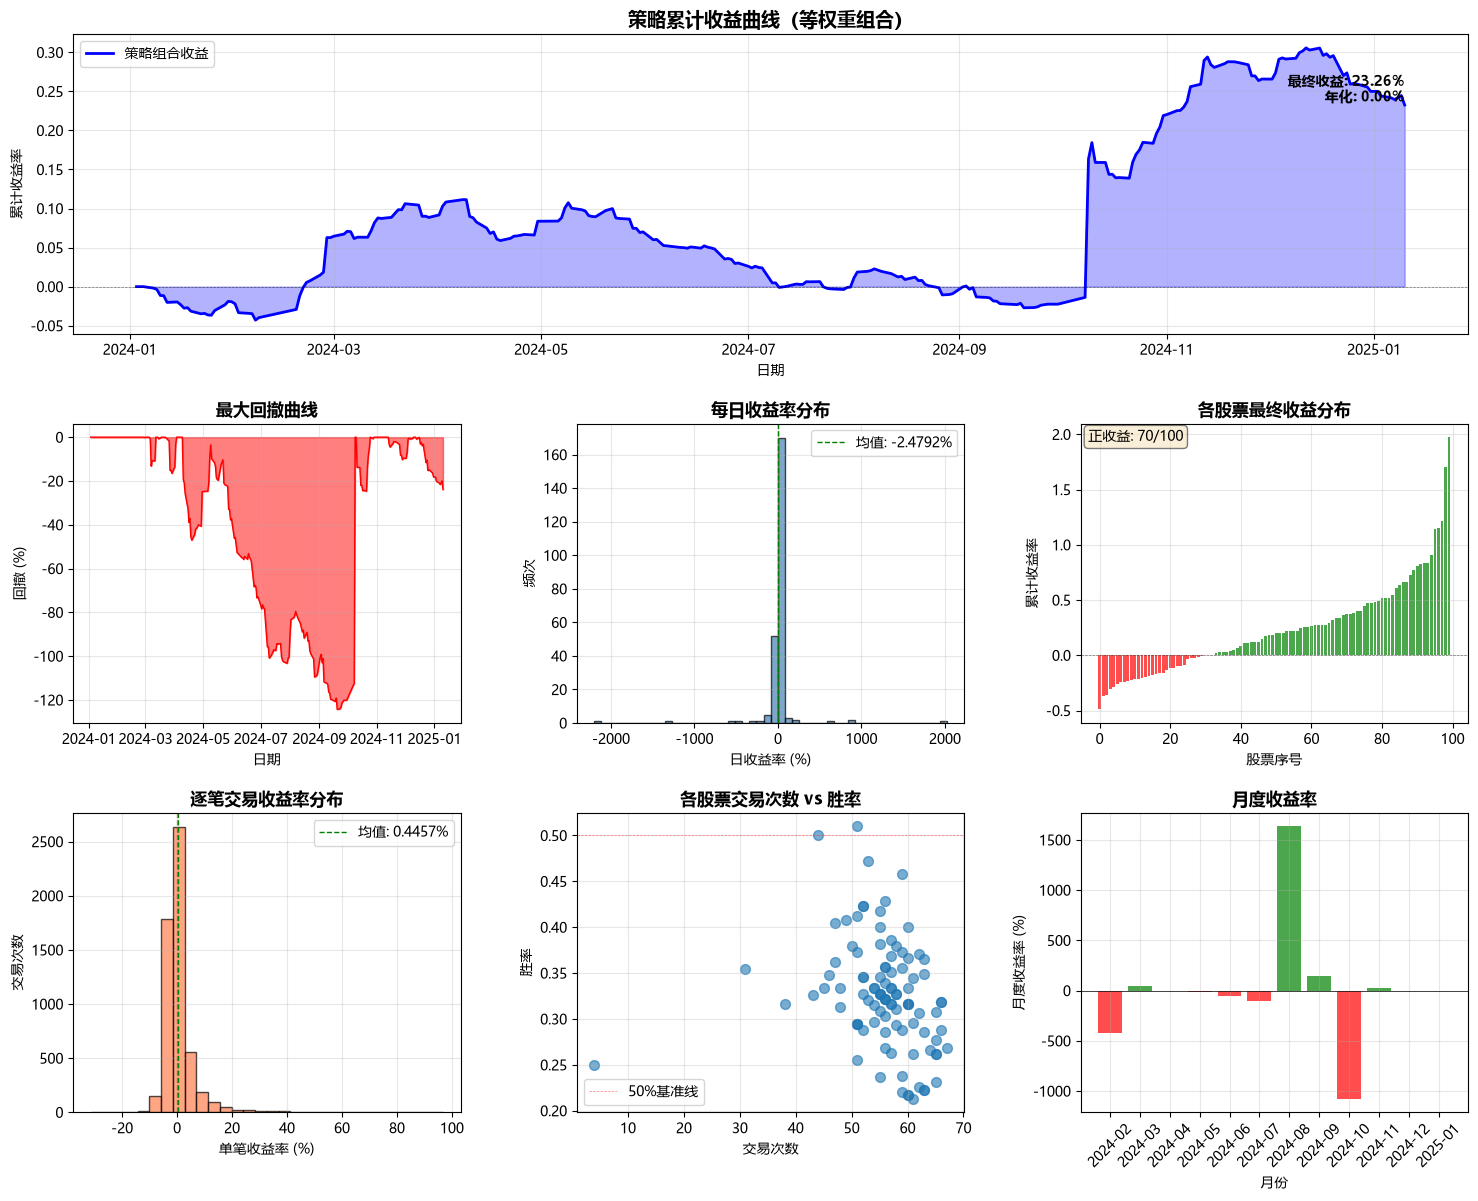

In [17]:
# ============ 可视化 ============
print("\n" + "="*60)
print("生成可视化图表")
print("="*60)

# 清理数据用于绘图
portfolio_returns_clean = pivot_returns['portfolio_returns'].replace([np.inf, -np.inf], np.nan).ffill().fillna(0)
daily_returns_clean = pivot_returns['daily_return'].replace([np.inf, -np.inf], 0).fillna(0)

fig = plt.figure(figsize=(18, 14))

# 创建网格布局
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 子图1：组合累计收益曲线
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(pivot_returns.index, portfolio_returns_clean, 
         label='策略组合收益', linewidth=2, color='blue')
ax1.fill_between(pivot_returns.index, 0, portfolio_returns_clean, 
                  alpha=0.3, color='blue')
ax1.set_title('策略累计收益曲线（等权重组合）', fontsize=14, fontweight='bold')
ax1.set_xlabel('日期')
ax1.set_ylabel('累计收益率')
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
ax1.grid(True, alpha=0.3)
ax1.legend()

final_return = portfolio_returns_clean.iloc[-1] if len(portfolio_returns_clean) > 0 else 0
if np.isfinite(final_return):
    ax1.text(pivot_returns.index[-1], final_return, 
             f'最终收益: {final_return:.2%}\n年化: {portfolio_metrics["年化收益率"]:.2%}',
             ha='right', va='bottom', fontsize=10, fontweight='bold')

# 子图2：最大回撤
ax2 = fig.add_subplot(gs[1, 0])
cummax = portfolio_returns_clean.expanding().max()
drawdown = np.zeros_like(portfolio_returns_clean)
mask = cummax != 0
drawdown[mask] = (portfolio_returns_clean[mask] - cummax[mask]) / cummax[mask] * 100
drawdown = np.nan_to_num(drawdown, nan=0, posinf=0, neginf=0)

ax2.fill_between(pivot_returns.index, 0, drawdown, color='red', alpha=0.5)
ax2.plot(pivot_returns.index, drawdown, color='red', linewidth=1)
ax2.set_title('最大回撤曲线', fontsize=12, fontweight='bold')
ax2.set_xlabel('日期')
ax2.set_ylabel('回撤 (%)')
ax2.grid(True, alpha=0.3)

# 子图3：每日收益率分布
ax3 = fig.add_subplot(gs[1, 1])
daily_returns_hist = daily_returns_clean[daily_returns_clean != 0]
if len(daily_returns_hist) > 0:
    ax3.hist(daily_returns_hist * 100, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    ax3.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax3.axvline(x=daily_returns_hist.mean() * 100, color='green', linestyle='--', linewidth=1, 
                label=f'均值: {daily_returns_hist.mean():.4%}')
    ax3.set_title('每日收益率分布', fontsize=12, fontweight='bold')
    ax3.set_xlabel('日收益率 (%)')
    ax3.set_ylabel('频次')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# 子图4：各股票最终收益
ax4 = fig.add_subplot(gs[1, 2])
if stock_metrics:
    stock_returns_sorted = sorted([m['total_return'] for m in stock_metrics if np.isfinite(m['total_return'])])
    if stock_returns_sorted:
        colors = ['green' if x > 0 else 'red' for x in stock_returns_sorted]
        ax4.bar(range(len(stock_returns_sorted)), stock_returns_sorted, color=colors, alpha=0.7)
        ax4.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
        ax4.set_title('各股票最终收益分布', fontsize=12, fontweight='bold')
        ax4.set_xlabel('股票序号')
        ax4.set_ylabel('累计收益率')
        ax4.grid(True, alpha=0.3)
        
        positive_count = sum(1 for x in stock_returns_sorted if x > 0)
        total_count = len(stock_returns_sorted)
        ax4.text(0.02, 0.98, f'正收益: {positive_count}/{total_count}', 
                 transform=ax4.transAxes, fontsize=10, 
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 子图5：逐笔收益分布
ax5 = fig.add_subplot(gs[2, 0])
if len(all_trades) > 0:
    ax5.hist(all_trades * 100, bins=30, color='coral', alpha=0.7, edgecolor='black')
    ax5.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax5.axvline(x=all_trades.mean() * 100, color='green', linestyle='--', linewidth=1, 
                label=f'均值: {all_trades.mean():.4%}')
    ax5.set_title('逐笔交易收益率分布', fontsize=12, fontweight='bold')
    ax5.set_xlabel('单笔收益率 (%)')
    ax5.set_ylabel('交易次数')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

# 子图6：各股票交易次数与胜率
ax6 = fig.add_subplot(gs[2, 1])
if stock_metrics:
    trade_counts = [m['trade_count'] for m in stock_metrics]
    win_rates = [m['win_rate'] for m in stock_metrics]
    ax6.scatter(trade_counts, win_rates, alpha=0.6, s=50)
    ax6.set_xlabel('交易次数')
    ax6.set_ylabel('胜率')
    ax6.set_title('各股票交易次数 vs 胜率', fontsize=12, fontweight='bold')
    ax6.grid(True, alpha=0.3)
    ax6.axhline(y=0.5, color='red', linestyle='--', linewidth=0.5, alpha=0.5, label='50%基准线')
    ax6.legend()

# 子图7：月度收益率
ax7 = fig.add_subplot(gs[2, 2])
if len(pivot_returns) > 0:
    monthly_returns = pivot_returns['portfolio_returns'].resample('ME').last().pct_change()
    monthly_returns = monthly_returns.replace([np.inf, -np.inf], np.nan).dropna()
    
    if len(monthly_returns) > 0:
        months = monthly_returns.index.strftime('%Y-%m')
        returns_pct = monthly_returns.values * 100
        colors = ['green' if x > 0 else 'red' for x in returns_pct]
        ax7.bar(range(len(months)), returns_pct, color=colors, alpha=0.7)
        ax7.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        ax7.set_title('月度收益率', fontsize=12, fontweight='bold')
        ax7.set_xlabel('月份')
        ax7.set_ylabel('月度收益率 (%)')
        ax7.set_xticks(range(0, len(months), max(1, len(months)//12)))
        ax7.set_xticklabels(months[::max(1, len(months)//12)], rotation=45)
        ax7.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
df = pd.read_csv('../extracted_data/stk_100.csv')
print("数据形状:", df.shape)
print("\n数据前几行:")
print(df.head())
print("\n数据信息:")
print(df.info())
print("\n缺失值统计:")
print(df.isnull().sum())
print("\nts_code唯一值数量:", df['ts_code'].nunique())
print("股票代码示例:", df['ts_code'].unique()[:5])

数据形状: (24678, 11)

数据前几行:
     ts_code  trade_date  open  high   low  close  pre_close  change  pct_chg  \
0  000005.SZ  2024-01-02  1.08  1.12  1.08   1.12       1.07    0.05   4.6729   
1  000005.SZ  2024-01-03  1.17  1.18  1.13   1.14       1.12    0.02   1.7857   
2  000005.SZ  2024-01-04  1.13  1.18  1.12   1.17       1.14    0.03   2.6316   
3  000005.SZ  2024-01-05  1.16  1.17  1.11   1.11       1.17   -0.06  -5.1282   
4  000005.SZ  2024-01-08  1.09  1.10  1.05   1.07       1.11   -0.04  -3.6036   

         vol     amount  
0   63028.00   6967.071  
1  274455.55  31989.773  
2  189486.02  21868.559  
3  151984.57  17158.063  
4   99076.57  10704.465  

数据信息:
<class 'pandas.DataFrame'>
RangeIndex: 24678 entries, 0 to 24677
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ts_code     24678 non-null  str    
 1   trade_date  24678 non-null  str    
 2   open        24678 non-null  float64
 3   high        2467

In [2]:
# ============ 计算MA5、MA10和MA5斜率 ============
print("\n" + "="*60)
print("计算MA5、MA10和MA5斜率")
print("="*60)

# 确保trade_date是日期类型并排序
df['trade_date'] = pd.to_datetime(df['trade_date'])

# 按股票分组计算MA
def calculate_ma(group):
    """计算每只股票的MA5和MA10"""
    group = group.sort_values('trade_date').copy()
    group['MA5'] = group['close'].rolling(window=5).mean()
    group['MA10'] = group['close'].rolling(window=10).mean()
    return group

print("计算移动平均线...")
df_list = []
for code in df['ts_code'].unique():
    group = df[df['ts_code'] == code].copy()
    group = calculate_ma(group)
    df_list.append(group)

df = pd.concat(df_list, ignore_index=True)

# 计算MA5斜率（使用5日均线的变化率）
df['MA5_slope'] = df.groupby('ts_code')['MA5'].pct_change()
# 或者使用差值
# df['MA5_slope'] = df.groupby('ts_code')['MA5'].diff()

print(f"✅ MA计算完成")
print(f"MA5均值: {df['MA5'].mean():.4f}")
print(f"MA10均值: {df['MA10'].mean():.4f}")
print(f"MA5斜率均值: {df['MA5_slope'].mean():.6f}")

# ============ 统计每只股票的缺失情况 ============
print("\n" + "="*60)
print("统计每只股票各因子的缺失情况")
print("="*60)

# 需要统计的因子列
factor_columns = ['MA5', 'MA10', 'MA5_slope']

# 按股票分组统计
stock_missing_stats = []

for code in df['ts_code'].unique():
    stock_data = df[df['ts_code'] == code]
    total_rows = len(stock_data)
    
    stats = {
        'ts_code': code,
        'total_rows': total_rows
    }
    
    # 统计每个因子的缺失行数
    for col in factor_columns:
        missing_count = stock_data[col].isnull().sum()
        missing_ratio = missing_count / total_rows if total_rows > 0 else 0
        stats[f'{col}_missing'] = missing_count
        stats[f'{col}_missing_ratio'] = missing_ratio
    
    stock_missing_stats.append(stats)

# 转换为DataFrame
missing_stats_df = pd.DataFrame(stock_missing_stats)

# 计算汇总统计
print("\n【各因子缺失统计汇总】")
for col in factor_columns:
    total_missing = missing_stats_df[f'{col}_missing'].sum()
    avg_missing_ratio = missing_stats_df[f'{col}_missing_ratio'].mean()
    max_missing_ratio = missing_stats_df[f'{col}_missing_ratio'].max()
    min_missing_ratio = missing_stats_df[f'{col}_missing_ratio'].min()
    
    print(f"\n{col}:")
    print(f"  总缺失行数: {total_missing:,}")
    print(f"  平均缺失比例: {avg_missing_ratio:.4%}")
    print(f"  最大缺失比例: {max_missing_ratio:.4%}")
    print(f"  最小缺失比例: {min_missing_ratio:.4%}")

# 显示缺失比例最高的5只股票
print("\n【缺失比例最高的5只股票（MA5）】")
top_missing = missing_stats_df.nlargest(5, 'MA5_missing_ratio')
print(top_missing[['ts_code', 'total_rows', 'MA5_missing', 'MA5_missing_ratio']].to_string(index=False))

# 显示缺失比例最低的5只股票
print("\n【缺失比例最低的5只股票（MA5）】")
bottom_missing = missing_stats_df.nsmallest(5, 'MA5_missing_ratio')
print(bottom_missing[['ts_code', 'total_rows', 'MA5_missing', 'MA5_missing_ratio']].to_string(index=False))

# ============ 总体缺失统计 ============
print("\n" + "="*60)
print("总体缺失统计")
print("="*60)

total_rows_all = len(df)
print(f"数据总行数: {total_rows_all:,}")

for col in factor_columns:
    total_missing = df[col].isnull().sum()
    missing_ratio = total_missing / total_rows_all if total_rows_all > 0 else 0
    print(f"{col}:")
    print(f"  缺失行数: {total_missing:,}")
    print(f"  缺失比例: {missing_ratio:.4%}")


计算MA5、MA10和MA5斜率
计算移动平均线...
✅ MA计算完成
MA5均值: 18.5649
MA10均值: 18.5305
MA5斜率均值: -0.000383

统计每只股票各因子的缺失情况

【各因子缺失统计汇总】

MA5:
  总缺失行数: 400
  平均缺失比例: 1.6912%
  最大缺失比例: 10.0000%
  最小缺失比例: 1.6064%

MA10:
  总缺失行数: 900
  平均缺失比例: 3.8053%
  最大缺失比例: 22.5000%
  最小缺失比例: 3.6145%

MA5_slope:
  总缺失行数: 500
  平均缺失比例: 2.1140%
  最大缺失比例: 12.5000%
  最小缺失比例: 2.0080%

【缺失比例最高的5只股票（MA5）】
  ts_code  total_rows  MA5_missing  MA5_missing_ratio
000005.SZ          40            4           0.100000
603160.SH         239            4           0.016736
000609.SZ         248            4           0.016129
300338.SZ         248            4           0.016129
600360.SH         248            4           0.016129

【缺失比例最低的5只股票（MA5）】
  ts_code  total_rows  MA5_missing  MA5_missing_ratio
000011.SZ         249            4           0.016064
000025.SZ         249            4           0.016064
000050.SZ         249            4           0.016064
000422.SZ         249            4           0.016064
000429.SZ         24

In [3]:
# ============ 计算删除所有缺失行数之后的数据对比 ============
print("\n" + "="*60)
print("删除所有缺失行之后的数据对比（模拟）")
print("="*60)

# 需要统计的因子列
factor_columns = ['MA5', 'MA10', 'MA5_slope']

# 1. 统计每只股票在删除缺失值前后的数据量对比
print("\n【每只股票删除缺失前后数据量对比】")

comparison_data = []

for code in df['ts_code'].unique():
    stock_data = df[df['ts_code'] == code]
    total_rows = len(stock_data)
    
    # 删除任何因子列有缺失的行
    clean_data = stock_data.dropna(subset=factor_columns)
    clean_rows = len(clean_data)
    
    # 计算保留比例
    keep_ratio = clean_rows / total_rows if total_rows > 0 else 0
    removed_rows = total_rows - clean_rows
    removed_ratio = removed_rows / total_rows if total_rows > 0 else 0
    
    comparison_data.append({
        'ts_code': code,
        '原始行数': total_rows,
        '删除后行数': clean_rows,
        '删除行数': removed_rows,
        '保留比例': keep_ratio,
        '删除比例': removed_ratio
    })

comparison_df = pd.DataFrame(comparison_data)

# 显示汇总统计
print("\n【删除缺失值前后对比汇总】")
print(f"原始总行数: {comparison_df['原始行数'].sum():,}")
print(f"删除后总行数: {comparison_df['删除后行数'].sum():,}")
print(f"总删除行数: {comparison_df['删除行数'].sum():,}")
print(f"总体保留比例: {comparison_df['删除后行数'].sum() / comparison_df['原始行数'].sum():.4%}")
print(f"总体删除比例: {comparison_df['删除行数'].sum() / comparison_df['原始行数'].sum():.4%}")

print("\n【每只股票删除情况统计】")
print(f"平均保留比例: {comparison_df['保留比例'].mean():.4%}")
print(f"平均删除比例: {comparison_df['删除比例'].mean():.4%}")
print(f"最大删除比例: {comparison_df['删除比例'].max():.4%}")
print(f"最小删除比例: {comparison_df['删除比例'].min():.4%}")

# 显示删除比例最高的5只股票
print("\n【删除比例最高的5只股票】")
top_removed = comparison_df.nlargest(5, '删除比例')
print(top_removed[['ts_code', '原始行数', '删除行数', '删除比例', '保留比例']].to_string(index=False))

# 显示删除比例最低的5只股票
print("\n【删除比例最低的5只股票】")
bottom_removed = comparison_df.nsmallest(5, '删除比例')
print(bottom_removed[['ts_code', '原始行数', '删除行数', '删除比例', '保留比例']].to_string(index=False))

# 2. 统计删除缺失值后各因子的数据完整性
print("\n" + "="*60)
print("删除缺失值后各因子的数据完整性")
print("="*60)

# 创建一个干净的DataFrame（只用于统计，不修改原数据）
clean_df = df.dropna(subset=factor_columns)

print(f"清洗后数据总行数: {len(clean_df):,}")

for col in factor_columns:
    total = len(clean_df)
    missing_count = clean_df[col].isnull().sum()
    missing_ratio = missing_count / total if total > 0 else 0
    print(f"{col}:")
    print(f"  数据行数: {total:,}")
    print(f"  缺失行数: {missing_count:,}")
    print(f"  缺失比例: {missing_ratio:.4%}")
    print(f"  均值: {clean_df[col].mean():.6f}")
    print(f"  标准差: {clean_df[col].std():.6f}")

# 3. 对比删除前后各因子的统计量变化
print("\n" + "="*60)
print("删除前后各因子统计量对比")
print("="*60)

for col in factor_columns:
    print(f"\n【{col}】")
    
    # 原始数据统计
    orig_mean = df[col].mean()
    orig_std = df[col].std()
    orig_min = df[col].min()
    orig_max = df[col].max()
    orig_count = df[col].count()
    
    # 清洗后数据统计
    clean_mean = clean_df[col].mean()
    clean_std = clean_df[col].std()
    clean_min = clean_df[col].min()
    clean_max = clean_df[col].max()
    clean_count = clean_df[col].count()
    
    print(f"  指标          原始数据        删除缺失后")
    print(f"  {'-'*40}")
    print(f"  数据量        {orig_count:>12,}    {clean_count:>12,}")
    print(f"  均值          {orig_mean:>12.6f}    {clean_mean:>12.6f}")
    print(f"  标准差        {orig_std:>12.6f}    {clean_std:>12.6f}")
    print(f"  最小值        {orig_min:>12.6f}    {clean_min:>12.6f}")
    print(f"  最大值        {orig_max:>12.6f}    {clean_max:>12.6f}")

# 4. 按股票统计清洗后的数据分布
print("\n" + "="*60)
print("清洗后各股票数据分布")
print("="*60)

# 统计每只股票清洗后的数据量
stock_clean_count = clean_df.groupby('ts_code').size().reset_index(name='clean_count')
stock_original_count = df.groupby('ts_code').size().reset_index(name='original_count')
stock_compare = pd.merge(stock_original_count, stock_clean_count, on='ts_code', how='left')
stock_compare['clean_count'] = stock_compare['clean_count'].fillna(0).astype(int)
stock_compare['keep_ratio'] = stock_compare['clean_count'] / stock_compare['original_count']

print(f"清洗后仍有数据的股票数量: {len(stock_compare[stock_compare['clean_count'] > 0])}")
print(f"清洗后完全无数据的股票数量: {len(stock_compare[stock_compare['clean_count'] == 0])}")

if len(stock_compare[stock_compare['clean_count'] == 0]) > 0:
    print("\n【清洗后完全无数据的股票】")
    print(stock_compare[stock_compare['clean_count'] == 0]['ts_code'].tolist())

print(f"\n清洗后各股票数据量统计:")
print(f"  平均保留行数: {stock_compare['clean_count'].mean():.1f}")
print(f"  最大保留行数: {stock_compare['clean_count'].max()}")
print(f"  最小保留行数: {stock_compare['clean_count'].min()}")


删除所有缺失行之后的数据对比（模拟）

【每只股票删除缺失前后数据量对比】

【删除缺失值前后对比汇总】
原始总行数: 24,678
删除后总行数: 23,778
总删除行数: 900
总体保留比例: 96.3530%
总体删除比例: 3.6470%

【每只股票删除情况统计】
平均保留比例: 96.1947%
平均删除比例: 3.8053%
最大删除比例: 22.5000%
最小删除比例: 3.6145%

【删除比例最高的5只股票】
  ts_code  原始行数  删除行数     删除比例     保留比例
000005.SZ    40     9 0.225000 0.775000
603160.SH   239     9 0.037657 0.962343
000609.SZ   248     9 0.036290 0.963710
300338.SZ   248     9 0.036290 0.963710
600360.SH   248     9 0.036290 0.963710

【删除比例最低的5只股票】
  ts_code  原始行数  删除行数     删除比例     保留比例
000011.SZ   249     9 0.036145 0.963855
000025.SZ   249     9 0.036145 0.963855
000050.SZ   249     9 0.036145 0.963855
000422.SZ   249     9 0.036145 0.963855
000429.SZ   249     9 0.036145 0.963855

删除缺失值后各因子的数据完整性
清洗后数据总行数: 23,778
MA5:
  数据行数: 23,778
  缺失行数: 0
  缺失比例: 0.0000%
  均值: 18.508908
  标准差: 23.338146
MA10:
  数据行数: 23,778
  缺失行数: 0
  缺失比例: 0.0000%
  均值: 18.530519
  标准差: 23.359668
MA5_slope:
  数据行数: 23,778
  缺失行数: 0
  缺失比例: 0.0000%
  均值: -0.000257
  标准差: 0.017270

删除前后各

开始完整回测流程

1. 数据读取
数据形状: (24678, 11)
股票数量: 100
日期范围: 2024-01-02 到 2025-01-10

2. 因子计算
计算因子...
  处理进度: 20/100
  处理进度: 40/100
  处理进度: 60/100
  处理进度: 80/100
✅ 因子计算完成

3. 数据清洗
清洗前数据行数: 24,678
  MA5 缺失: 400 (1.6209%)
  MA10 缺失: 900 (3.6470%)
  MA5_slope 缺失: 500 (2.0261%)
  REF1MA5 缺失: 500 (2.0261%)
  REF1MA10 缺失: 1,000 (4.0522%)

清洗后数据行数: 23,678
删除行数: 1,000
数据保留率: 95.9478%

清洗后有数据的股票数量: 100
平均每只股票行数: 236.8
最小行数: 30
最大行数: 239

数据量 >= 10行的股票数量: 100
过滤后数据行数: 23,678

4. 信号生成
生成信号...
  处理进度: 20/100
  处理进度: 40/100
  处理进度: 60/100
  处理进度: 80/100
✅ 信号生成完成
总开仓信号数: 808
总平仓信号数: 804

验证信号顺序...
  ✅ 所有信号顺序正确（开仓→平仓交替）

5. 回测执行
执行回测...
  处理进度: 20/100
  处理进度: 40/100
  处理进度: 60/100
  处理进度: 80/100
✅ 回测执行完成

6. 计算累计收益
计算累计收益...
  处理进度: 20/100
  处理进度: 40/100
  处理进度: 60/100
  处理进度: 80/100
✅ 累计收益计算完成

7. 计算绩效指标

【组合表现指标】
总收益率: -44675.5386%
年化收益率: 0.0000%
夏普比率: 1.0524
日胜率: 43.5146%
最大回撤: -801.5061%
年化波动率: 12476.6023%

【逐笔交易统计】
总交易笔数: 801
逐笔胜率: 43.5705%
平均单笔收益率: 1.9788%
最大单笔收益: 44.7110%
最小单笔收益: -34.9148%
平均盈利: 10.946

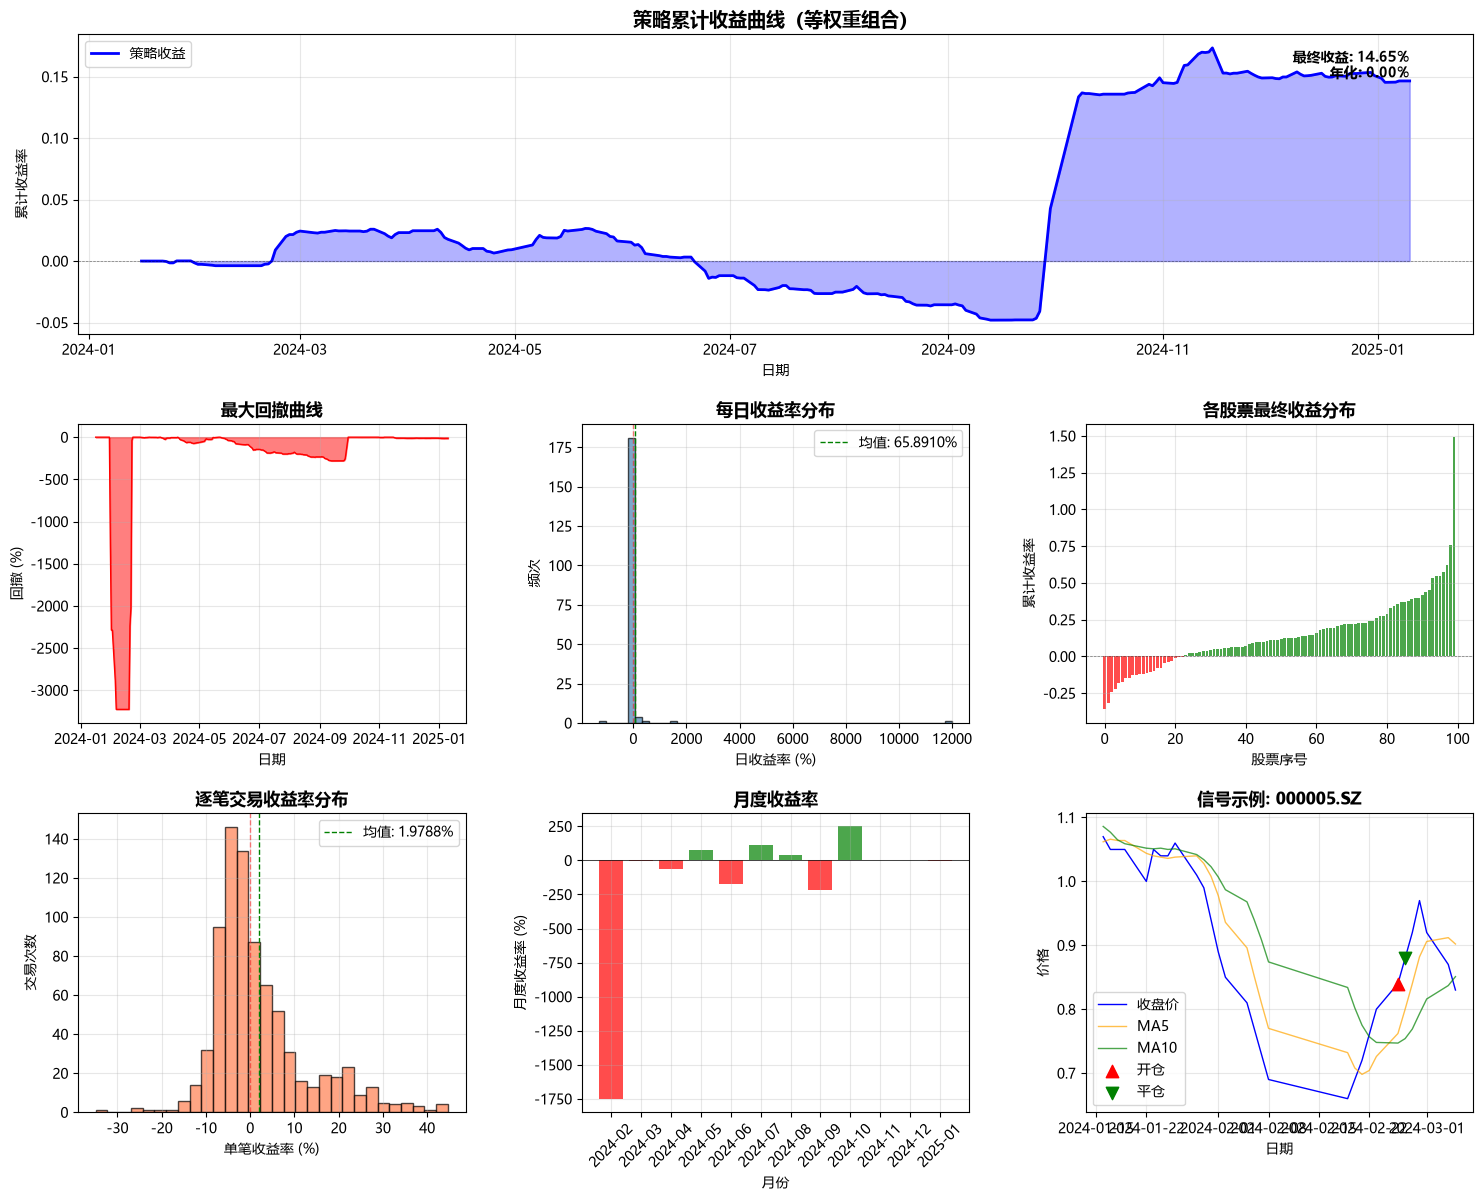


回测总结

【策略参数】
- 均线周期: MA5 / MA10
- 开仓条件: 前1MA5<=前1MA10 且 当前MA5>MA10 且 MA5斜率>=0
- 平仓条件: 前1MA5>=前1MA10 且 当前MA5<MA10
- 股票池: 100 只股票
- 回测期间: 2024-01-16 00:00:00 到 2025-01-10 00:00:00

【组合表现】
- 总收益率: -44675.5386%
- 年化收益率: 0.0000%
- 夏普比率: 1.0524
- 最大回撤: -801.5061%
- 日胜率: 43.5146%

【交易统计】
- 总开仓信号: 808
- 总平仓信号: 804
- 完成交易: 801
- 逐笔胜率: 43.5705%

回测流程完成！


In [ ]:
# ============ 完整回测流程 ============
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False

print("="*60)
print("开始完整回测流程")
print("="*60)

# ============ 1. 数据读取 ============
print("\n" + "="*60)
print("1. 数据读取")
print("="*60)

df = pd.read_csv('../extracted_data/stk_100.csv')
print(f"数据形状: {df.shape}")
print(f"股票数量: {df['ts_code'].nunique()}")
print(f"日期范围: {df['trade_date'].min()} 到 {df['trade_date'].max()}")

# ============ 2. 因子计算 ============
print("\n" + "="*60)
print("2. 因子计算")
print("="*60)

# 确保trade_date是日期类型
df['trade_date'] = pd.to_datetime(df['trade_date'])

def calculate_factors(group):
    """计算所有因子：MA5, MA10, MA5_slope, REF1MA5, REF1MA10"""
    group = group.sort_values('trade_date').copy()
    
    # 计算MA5和MA10
    group['MA5'] = group['close'].rolling(window=5).mean()
    group['MA10'] = group['close'].rolling(window=10).mean()
    
    # 计算MA5斜率（使用变化率）
    group['MA5_slope'] = group['MA5'].pct_change()
    
    # 计算前1期的MA5和MA10（shift(1)）
    group['REF1MA5'] = group['MA5'].shift(1)
    group['REF1MA10'] = group['MA10'].shift(1)
    group['close1'] = group['close'].shift(1)
    group['MA5-10'] = group['MA5']-group['MA10']
    
    return group

print("计算因子...")
df_list = []
unique_codes = df['ts_code'].unique().tolist()
for i, code in enumerate(unique_codes):
    if i % 20 == 0 and i > 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    
    group = df[df['ts_code'] == code].copy()
    group = calculate_factors(group)
    df_list.append(group)

df = pd.concat(df_list, ignore_index=True)
print(f"✅ 因子计算完成")

# ============ 3. 数据清洗 ============
print("\n" + "="*60)
print("3. 数据清洗")
print("="*60)

# 需要使用的因子列
factor_columns = ['MA5', 'MA10', 'MA5_slope', 'REF1MA5', 'REF1MA10']

# 统计清洗前数据
print(f"清洗前数据行数: {len(df):,}")

# 检查缺失值
for col in factor_columns:
    missing_count = df[col].isnull().sum()
    missing_ratio = missing_count / len(df) if len(df) > 0 else 0
    print(f"  {col} 缺失: {missing_count:,} ({missing_ratio:.4%})")

# 删除任何因子列有缺失的行（保留原始数据副本）
df_clean = df.dropna(subset=factor_columns).copy()
print(f"\n清洗后数据行数: {len(df_clean):,}")
print(f"删除行数: {len(df) - len(df_clean):,}")
print(f"数据保留率: {len(df_clean) / len(df):.4%}")

# 重置索引
df_clean = df_clean.reset_index(drop=True)

# 检查清洗后各股票的数据量
stock_counts = df_clean.groupby('ts_code').size()
print(f"\n清洗后有数据的股票数量: {len(stock_counts)}")
print(f"平均每只股票行数: {stock_counts.mean():.1f}")
print(f"最小行数: {stock_counts.min()}")
print(f"最大行数: {stock_counts.max()}")

# 剔除数据量不足的股票（至少需要10行数据）
min_rows = 10
valid_stocks = stock_counts[stock_counts >= min_rows].index.tolist()
print(f"\n数据量 >= {min_rows}行的股票数量: {len(valid_stocks)}")
df_clean = df_clean[df_clean['ts_code'].isin(valid_stocks)].copy()
print(f"过滤后数据行数: {len(df_clean):,}")

# ============ 4. 信号生成 ============
print("\n" + "="*60)
print("4. 信号生成")
print("="*60)

def generate_signals(group):
    """生成交易信号
    开仓条件：
      1. 前1期MA5 <= 前1期MA10 且 当前MA5 > 当前MA10（金叉）且当前收盘价大于前1收盘价
      2. 当前MA5斜率 >= 0
    平仓条件：
      （前1期MA5 >= 前1期MA10 且 当前MA5 < 当前MA10（死叉）） 或 MA5-MA10/MA5 > 0.05
    严格保证：开仓信号在平仓信号之前
    """
    group = group.sort_values('trade_date').copy()
    
    # 初始化信号
    group['entry_signal'] = False
    group['exit_signal'] = False
    
    position = 0  # 0=空仓, 1=持仓
    position_count = 0
    
    for i in range(1, len(group)):  # 从第2行开始（需要REF1MA5和REF1MA10）
        # 获取当前值
        curr_ma5 = group.iloc[i]['MA5']
        curr_ma10 = group.iloc[i]['MA10']
        prev_ma5 = group.iloc[i]['REF1MA5']
        prev_ma10 = group.iloc[i]['REF1MA10']
        ma5_slope = group.iloc[i]['MA5_slope']
        close0 = group.iloc[i]['close']
        close1 = group.iloc[i]['close1']
        ma5_10_5 = group.iloc[i]['MA5-10'] / group.iloc[i]['MA5']
        
        
        # 开仓条件：前1MA5 <= 前1MA10 且 当前MA5 > MA10 且 MA5斜率 >= 0
        entry_condition = (prev_ma5 <= prev_ma10) and (curr_ma5 > curr_ma10) and (ma5_slope >= 0) and (close0 > close1)
        
        # 平仓条件：前1MA5 >= 前1MA10 且 当前MA5 < 当前MA10
        exit_condition = ((prev_ma5 >= prev_ma10) and (curr_ma5 < curr_ma10)) or (ma5_10_5 >= 0.05)
        
        # 严格顺序控制
        if position == 0 and entry_condition:
            group.loc[group.index[i], 'entry_signal'] = True
            position = 1
            position_count += 1
        
        elif position == 1 and exit_condition:
            group.loc[group.index[i], 'exit_signal'] = True
            position = 0
    
    group['total_trades'] = position_count
    return group

print("生成信号...")
df_list = []
for i, code in enumerate(valid_stocks):
    if i % 20 == 0 and i > 0:
        print(f"  处理进度: {i}/{len(valid_stocks)}")
    
    group = df_clean[df_clean['ts_code'] == code].copy()
    group = generate_signals(group)
    df_list.append(group)

df_signals = pd.concat(df_list, ignore_index=True)
print(f"✅ 信号生成完成")
print(f"总开仓信号数: {df_signals['entry_signal'].sum():,}")
print(f"总平仓信号数: {df_signals['exit_signal'].sum():,}")

# 验证信号顺序
print("\n验证信号顺序...")
signal_df = df_signals[df_signals['entry_signal'] | df_signals['exit_signal']].copy()
signal_df = signal_df.sort_values(['ts_code', 'trade_date'])

valid_sequence = True
for code in signal_df['ts_code'].unique():
    code_signals = signal_df[signal_df['ts_code'] == code]
    signals_list = code_signals[['trade_date', 'entry_signal', 'exit_signal']].values
    pos = 0
    for date, entry, exit in signals_list:
        if entry:
            if pos == 1:
                print(f"  ⚠️ {code} 在 {date} 重复开仓")
                valid_sequence = False
            pos = 1
        if exit:
            if pos == 0:
                print(f"  ⚠️ {code} 在 {date} 重复平仓")
                valid_sequence = False
            pos = 0

if valid_sequence:
    print("  ✅ 所有信号顺序正确（开仓→平仓交替）")

# ============ 5. 回测执行 ============
print("\n" + "="*60)
print("5. 回测执行")
print("="*60)

def backtest_strategy(group):
    """执行回测策略"""
    group = group.sort_values('trade_date').copy()
    group['trade_date'] = pd.to_datetime(group['trade_date'])
    
    # 初始化
    group['position'] = 0
    group['returns'] = 0.0
    group['trade_duration'] = 0
    group['entry_price'] = np.nan
    group['entry_date'] = pd.NaT
    
    position = 0
    entry_price = 0
    entry_date = None
    trade_count = 0
    trade_returns = []
    
    for i in range(len(group)):
        if position == 0 and group.iloc[i]['entry_signal'] == True:
            position = 1
            entry_price = group.iloc[i]['close']
            entry_date = group.iloc[i]['trade_date']
            group.loc[group.index[i], 'position'] = 1
            group.loc[group.index[i], 'entry_price'] = entry_price
            group.loc[group.index[i], 'entry_date'] = entry_date
            trade_count += 1
            
        elif position == 1 and group.iloc[i]['exit_signal'] == True:
            exit_price = group.iloc[i]['close']
            exit_date = group.iloc[i]['trade_date']
            trade_return = (exit_price - entry_price) / entry_price
            group.loc[group.index[i], 'returns'] = trade_return
            group.loc[group.index[i], 'trade_duration'] = (exit_date - entry_date).days
            group.loc[group.index[i], 'entry_price'] = entry_price
            group.loc[group.index[i], 'entry_date'] = entry_date
            trade_returns.append(trade_return)
            position = 0
            entry_price = 0
            entry_date = None
            group.loc[group.index[i], 'position'] = 0
            
        elif position == 1:
            group.loc[group.index[i], 'position'] = 1
            group.loc[group.index[i], 'entry_price'] = entry_price
            group.loc[group.index[i], 'entry_date'] = entry_date
    
    group['trade_count'] = trade_count
    group['trade_returns_list'] = str(trade_returns)
    
    return group

print("执行回测...")
df_list = []
for i, code in enumerate(valid_stocks):
    if i % 20 == 0 and i > 0:
        print(f"  处理进度: {i}/{len(valid_stocks)}")
    
    group = df_signals[df_signals['ts_code'] == code].copy()
    group = backtest_strategy(group)
    df_list.append(group)

df_backtest = pd.concat(df_list, ignore_index=True)
print(f"✅ 回测执行完成")

# ============ 6. 计算累计收益 ============
print("\n" + "="*60)
print("6. 计算累计收益")
print("="*60)

def calculate_cumulative_returns(group):
    """计算累计收益"""
    group = group.sort_values('trade_date').copy()
    group['returns'] = group['returns'].replace([np.inf, -np.inf], 0).fillna(0)
    group['cumulative_returns'] = (1 + group['returns']).cumprod() - 1
    group['cumulative_returns'] = group['cumulative_returns'].replace([np.inf, -np.inf], np.nan)
    group['cumulative_returns'] = group['cumulative_returns'].ffill().fillna(0)
    return group

print("计算累计收益...")
df_list = []
for i, code in enumerate(valid_stocks):
    if i % 20 == 0 and i > 0:
        print(f"  处理进度: {i}/{len(valid_stocks)}")
    
    group = df_backtest[df_backtest['ts_code'] == code].copy()
    group = calculate_cumulative_returns(group)
    df_list.append(group)

df_result = pd.concat(df_list, ignore_index=True)
print(f"✅ 累计收益计算完成")

# ============ 7. 计算指标 ============
print("\n" + "="*60)
print("7. 计算绩效指标")
print("="*60)

# 整体组合收益（等权重）
pivot_returns = df_result.pivot(index='trade_date', columns='ts_code', values='cumulative_returns')
pivot_returns['portfolio'] = pivot_returns.mean(axis=1)
pivot_returns['portfolio_returns'] = pivot_returns['portfolio'].ffill().fillna(0)
pivot_returns['portfolio_returns'] = pivot_returns['portfolio_returns'].replace([np.inf, -np.inf], np.nan).ffill().fillna(0)
pivot_returns['daily_return'] = pivot_returns['portfolio_returns'].pct_change().fillna(0)
pivot_returns['daily_return'] = pivot_returns['daily_return'].replace([np.inf, -np.inf], 0).fillna(0)

def calculate_metrics(returns_series):
    """计算各项指标"""
    returns = returns_series.replace([np.inf, -np.inf], np.nan).dropna()
    
    if len(returns) == 0:
        return {
            '总收益率': 0, '年化收益率': 0, '夏普比率': 0,
            '日胜率': 0, '最大回撤': 0, '波动率': 0
        }
    
    total_return = (1 + returns).prod() - 1
    if not np.isfinite(total_return):
        total_return = 0
    
    trading_days = 252
    years = len(returns) / trading_days
    annual_return = (1 + total_return) ** (1 / years) - 1 if years > 0 and total_return > -1 else 0
    
    daily_mean = returns.mean()
    daily_std = returns.std()
    sharpe_ratio = daily_mean / daily_std * np.sqrt(trading_days) if daily_std > 0 and np.isfinite(daily_mean) else 0
    win_rate_daily = (returns > 0).sum() / len(returns)
    
    cumprod = (1 + returns).cumprod()
    if len(cumprod) > 0 and np.all(np.isfinite(cumprod)):
        cummax = cumprod.expanding().max()
        drawdown = cumprod / cummax - 1
        max_drawdown = drawdown.min() if len(drawdown) > 0 else 0
        max_drawdown = max_drawdown if np.isfinite(max_drawdown) else 0
    else:
        max_drawdown = 0
    
    return {
        '总收益率': total_return,
        '年化收益率': annual_return,
        '夏普比率': sharpe_ratio,
        '日胜率': win_rate_daily,
        '最大回撤': max_drawdown,
        '波动率': daily_std * np.sqrt(trading_days) if np.isfinite(daily_std) else 0
    }

portfolio_metrics = calculate_metrics(pivot_returns['daily_return'])

print("\n【组合表现指标】")
print(f"总收益率: {portfolio_metrics['总收益率']:.4%}")
print(f"年化收益率: {portfolio_metrics['年化收益率']:.4%}")
print(f"夏普比率: {portfolio_metrics['夏普比率']:.4f}")
print(f"日胜率: {portfolio_metrics['日胜率']:.4%}")
print(f"最大回撤: {portfolio_metrics['最大回撤']:.4%}")
print(f"年化波动率: {portfolio_metrics['波动率']:.4%}")

# 逐笔交易统计
all_trades = df_result[df_result['returns'] != 0]['returns']
all_trades = all_trades.replace([np.inf, -np.inf], np.nan).dropna()

if len(all_trades) > 0:
    print("\n【逐笔交易统计】")
    print(f"总交易笔数: {len(all_trades)}")
    print(f"逐笔胜率: {(all_trades > 0).sum() / len(all_trades):.4%}")
    print(f"平均单笔收益率: {all_trades.mean():.4%}")
    print(f"最大单笔收益: {all_trades.max():.4%}")
    print(f"最小单笔收益: {all_trades.min():.4%}")
    
    win_trades = all_trades[all_trades > 0]
    loss_trades = all_trades[all_trades < 0]
    if len(win_trades) > 0:
        print(f"平均盈利: {win_trades.mean():.4%}")
    if len(loss_trades) > 0:
        print(f"平均亏损: {loss_trades.mean():.4%}")
    if len(loss_trades) > 0 and loss_trades.mean() != 0:
        profit_loss_ratio = abs(win_trades.mean() / loss_trades.mean()) if len(win_trades) > 0 else 0
        print(f"盈亏比: {profit_loss_ratio:.2f}")

# ============ 8. 可视化 ============
print("\n" + "="*60)
print("8. 生成可视化图表")
print("="*60)

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 子图1：组合累计收益曲线
ax1 = fig.add_subplot(gs[0, :])
portfolio_returns_clean = pivot_returns['portfolio_returns'].replace([np.inf, -np.inf], np.nan).ffill().fillna(0)
ax1.plot(pivot_returns.index, portfolio_returns_clean, linewidth=2, color='blue')
ax1.fill_between(pivot_returns.index, 0, portfolio_returns_clean, alpha=0.3, color='blue')
ax1.set_title('策略累计收益曲线（等权重组合）', fontsize=14, fontweight='bold')
ax1.set_xlabel('日期')
ax1.set_ylabel('累计收益率')
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
ax1.grid(True, alpha=0.3)
ax1.legend(['策略收益'])
final_return = portfolio_returns_clean.iloc[-1] if len(portfolio_returns_clean) > 0 else 0
if np.isfinite(final_return):
    ax1.text(pivot_returns.index[-1], final_return, 
             f'最终收益: {final_return:.2%}\n年化: {portfolio_metrics["年化收益率"]:.2%}',
             ha='right', va='bottom', fontsize=10, fontweight='bold')

# 子图2：最大回撤
ax2 = fig.add_subplot(gs[1, 0])
cummax = portfolio_returns_clean.expanding().max()
drawdown = np.zeros_like(portfolio_returns_clean)
mask = cummax != 0
drawdown[mask] = (portfolio_returns_clean[mask] - cummax[mask]) / cummax[mask] * 100
drawdown = np.nan_to_num(drawdown, nan=0, posinf=0, neginf=0)
ax2.fill_between(pivot_returns.index, 0, drawdown, color='red', alpha=0.5)
ax2.plot(pivot_returns.index, drawdown, color='red', linewidth=1)
ax2.set_title('最大回撤曲线', fontsize=12, fontweight='bold')
ax2.set_xlabel('日期')
ax2.set_ylabel('回撤 (%)')
ax2.grid(True, alpha=0.3)

# 子图3：每日收益率分布
ax3 = fig.add_subplot(gs[1, 1])
daily_returns_hist = pivot_returns['daily_return']
daily_returns_hist = daily_returns_hist[daily_returns_hist != 0].replace([np.inf, -np.inf], np.nan).dropna()
if len(daily_returns_hist) > 0:
    ax3.hist(daily_returns_hist * 100, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    ax3.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax3.axvline(x=daily_returns_hist.mean() * 100, color='green', linestyle='--', 
                linewidth=1, label=f'均值: {daily_returns_hist.mean():.4%}')
    ax3.set_title('每日收益率分布', fontsize=12, fontweight='bold')
    ax3.set_xlabel('日收益率 (%)')
    ax3.set_ylabel('频次')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# 子图4：各股票最终收益
ax4 = fig.add_subplot(gs[1, 2])
stock_metrics = []
for code in valid_stocks:
    stock_data = df_result[df_result['ts_code'] == code]
    stock_trades = stock_data[stock_data['returns'] != 0]['returns']
    if len(stock_trades) > 0:
        total_return = stock_data['cumulative_returns'].iloc[-1] if len(stock_data) > 0 else 0
        if np.isfinite(total_return):
            stock_metrics.append(total_return)
if stock_metrics:
    stock_returns_sorted = sorted(stock_metrics)
    colors = ['green' if x > 0 else 'red' for x in stock_returns_sorted]
    ax4.bar(range(len(stock_returns_sorted)), stock_returns_sorted, color=colors, alpha=0.7)
    ax4.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
    ax4.set_title('各股票最终收益分布', fontsize=12, fontweight='bold')
    ax4.set_xlabel('股票序号')
    ax4.set_ylabel('累计收益率')
    ax4.grid(True, alpha=0.3)

# 子图5：逐笔收益分布
ax5 = fig.add_subplot(gs[2, 0])
if len(all_trades) > 0:
    ax5.hist(all_trades * 100, bins=30, color='coral', alpha=0.7, edgecolor='black')
    ax5.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax5.axvline(x=all_trades.mean() * 100, color='green', linestyle='--', 
                linewidth=1, label=f'均值: {all_trades.mean():.4%}')
    ax5.set_title('逐笔交易收益率分布', fontsize=12, fontweight='bold')
    ax5.set_xlabel('单笔收益率 (%)')
    ax5.set_ylabel('交易次数')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

# 子图6：月度收益率
ax6 = fig.add_subplot(gs[2, 1])
if len(pivot_returns) > 0:
    monthly_returns = pivot_returns['portfolio_returns'].resample('ME').last().pct_change()
    monthly_returns = monthly_returns.replace([np.inf, -np.inf], np.nan).dropna()
    if len(monthly_returns) > 0:
        months = monthly_returns.index.strftime('%Y-%m')
        returns_pct = monthly_returns.values * 100
        colors = ['green' if x > 0 else 'red' for x in returns_pct]
        ax6.bar(range(len(months)), returns_pct, color=colors, alpha=0.7)
        ax6.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        ax6.set_title('月度收益率', fontsize=12, fontweight='bold')
        ax6.set_xlabel('月份')
        ax6.set_ylabel('月度收益率 (%)')
        ax6.set_xticks(range(0, len(months), max(1, len(months)//12)))
        ax6.set_xticklabels(months[::max(1, len(months)//12)], rotation=45)
        ax6.grid(True, alpha=0.3)

# 子图7：开平仓信号示例
ax7 = fig.add_subplot(gs[2, 2])
# 选择第一只有交易的股票展示
sample_code = None
for code in valid_stocks:
    stock_data = df_result[df_result['ts_code'] == code]
    if len(stock_data[stock_data['returns'] != 0]) > 0:
        sample_code = code
        break

if sample_code:
    sample_data = df_result[df_result['ts_code'] == sample_code].sort_values('trade_date')
    ax7.plot(sample_data['trade_date'], sample_data['close'], label='收盘价', linewidth=1, color='blue')
    ax7.plot(sample_data['trade_date'], sample_data['MA5'], label='MA5', linewidth=1, color='orange', alpha=0.7)
    ax7.plot(sample_data['trade_date'], sample_data['MA10'], label='MA10', linewidth=1, color='green', alpha=0.7)
    
    # 标记开仓信号
    entries = sample_data[sample_data['entry_signal']]
    exits = sample_data[sample_data['exit_signal']]
    if len(entries) > 0:
        ax7.scatter(entries['trade_date'], entries['close'], color='red', marker='^', s=80, label='开仓', zorder=5)
    if len(exits) > 0:
        ax7.scatter(exits['trade_date'], exits['close'], color='green', marker='v', s=80, label='平仓', zorder=5)
    
    ax7.set_title(f'信号示例: {sample_code}', fontsize=12, fontweight='bold')
    ax7.set_xlabel('日期')
    ax7.set_ylabel('价格')
    ax7.legend(loc='best')
    ax7.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============ 9. 总结输出 ============
print("\n" + "="*60)
print("回测总结")
print("="*60)

print(f"""
【策略参数】
- 均线周期: MA5 / MA10
- 开仓条件: 前1MA5<=前1MA10 且 当前MA5>MA10 且 MA5斜率>=0
- 平仓条件: 前1MA5>=前1MA10 且 当前MA5<MA10
- 股票池: {len(valid_stocks)} 只股票
- 回测期间: {df_result['trade_date'].min()} 到 {df_result['trade_date'].max()}

【组合表现】
- 总收益率: {portfolio_metrics['总收益率']:.4%}
- 年化收益率: {portfolio_metrics['年化收益率']:.4%}
- 夏普比率: {portfolio_metrics['夏普比率']:.4f}
- 最大回撤: {portfolio_metrics['最大回撤']:.4%}
- 日胜率: {portfolio_metrics['日胜率']:.4%}

【交易统计】
- 总开仓信号: {df_result['entry_signal'].sum():,}
- 总平仓信号: {df_result['exit_signal'].sum():,}
- 完成交易: {len(all_trades):,}
- 逐笔胜率: {(all_trades > 0).sum() / len(all_trades) if len(all_trades) > 0 else 0:.4%}
""")

print("="*60)
print("回测流程完成！")
print("="*60)

开始完整回测流程（修正版）

1. 数据读取
数据形状: (24678, 11)
股票数量: 100
日期范围: 2024-01-02 到 2025-01-10

2. 因子计算
计算因子...
  处理进度: 20/100
  处理进度: 40/100
  处理进度: 60/100
  处理进度: 80/100
✅ 因子计算完成

3. 数据清洗
清洗前数据行数: 24,678
  MA5 缺失: 400 (1.6209%)
  MA10 缺失: 900 (3.6470%)
  MA5_slope 缺失: 500 (2.0261%)
  REF1MA5 缺失: 500 (2.0261%)
  REF1MA10 缺失: 1,000 (4.0522%)

清洗后数据行数: 23,678
数据保留率: 95.9478%

清洗后有数据的股票数量: 100
平均每只股票行数: 236.8

数据量 >= 10行的股票数量: 100
过滤后数据行数: 23,678

4. 信号生成
生成信号...
  处理进度: 20/100
  处理进度: 40/100
  处理进度: 60/100
  处理进度: 80/100
✅ 信号生成完成
总开仓信号数: 223
总平仓信号数: 147

5. 回测执行（修正版）
执行回测...
  处理进度: 20/100
  处理进度: 40/100
  处理进度: 60/100
  处理进度: 80/100
✅ 回测执行完成

6. 计算组合指标（修正版）
构建等权重组合...

【组合表现指标（修正版）】
总收益率: 16.4105%
年化收益率: 17.3766%
夏普比率: 2.8643
日胜率: 23.0126%
最大回撤: -1.1370%
年化波动率: 5.6497%

7. 逐笔交易统计
总交易笔数: 147
逐笔胜率: 74.1497%
平均单笔收益率: 10.3374%
最大单笔收益: 86.6667%
最小单笔收益: -53.2125%
平均盈利: 17.9561%
平均亏损: -11.5161%
盈亏比: 1.56

8. 生成可视化图表


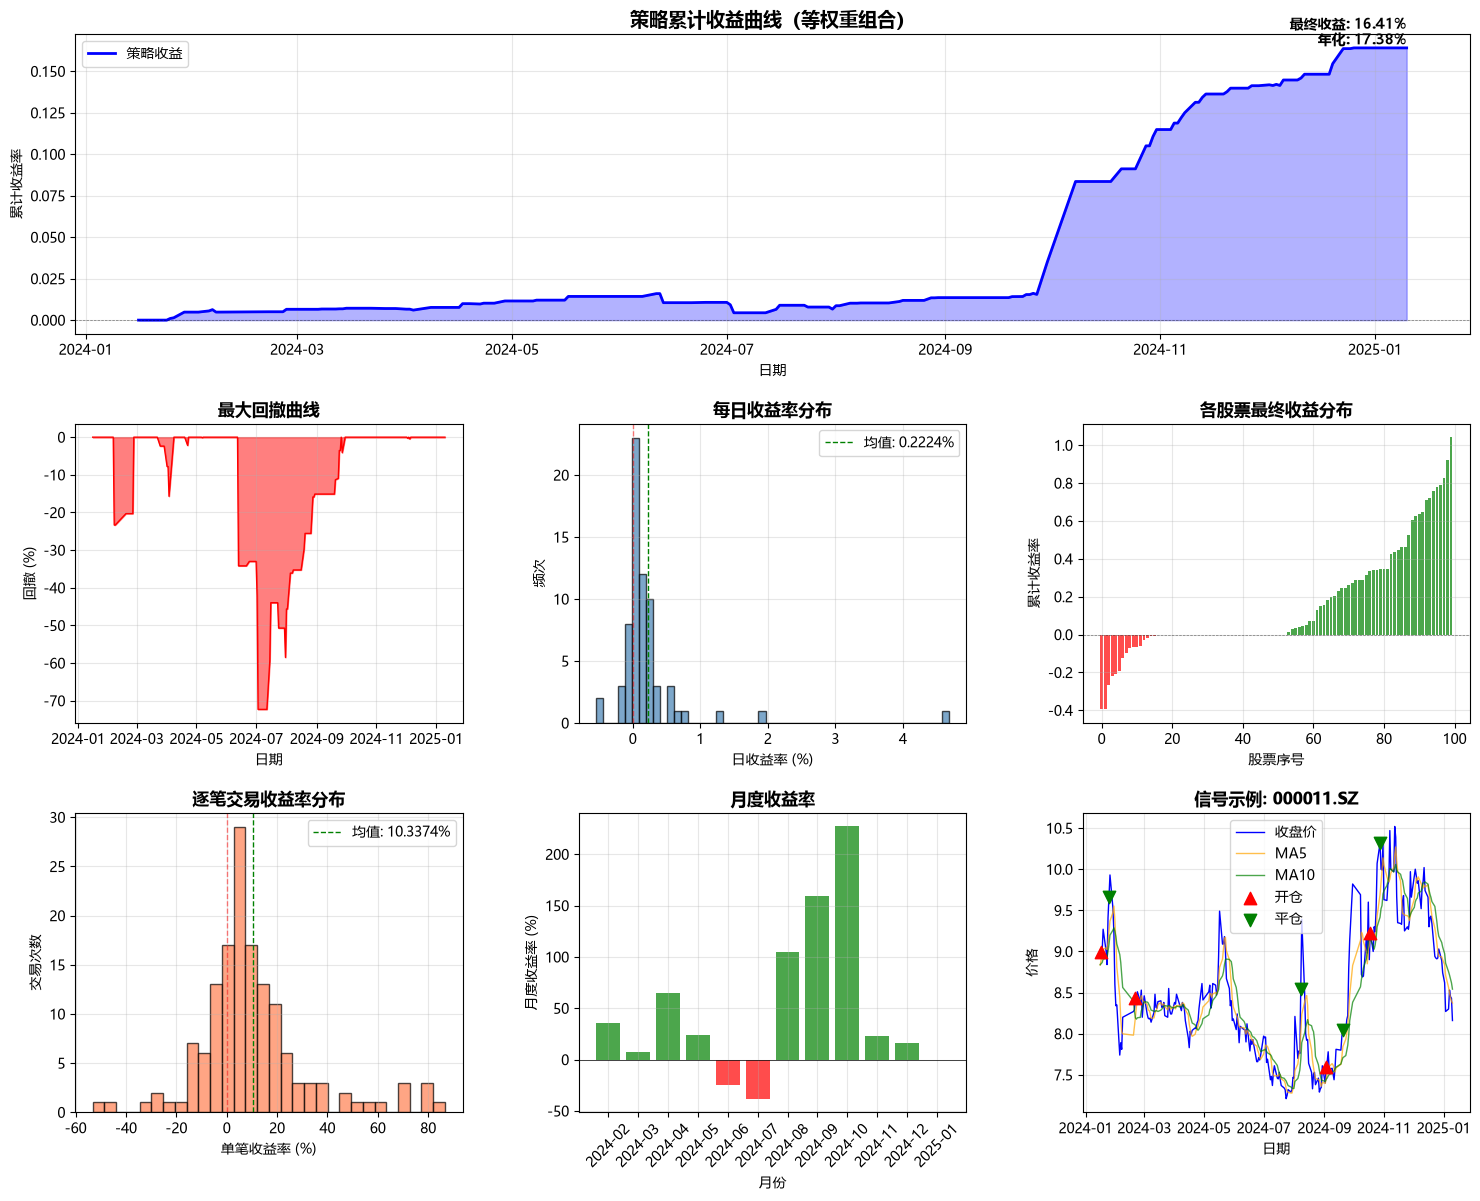


回测总结（修正版）

【策略参数】
- 均线周期: MA5 / MA10
- 开仓条件: 前1MA5<=前1MA10 且 当前MA5>MA10 且 MA5斜率>=0 且 close>close1
- 平仓条件: MA5斜率 >= 开仓斜率 * 1.88
- 股票池: 100 只股票
- 回测期间: 2024-01-16 00:00:00 到 2025-01-10 00:00:00

【组合表现】
- 总收益率: 16.4105%
- 年化收益率: 17.3766%
- 夏普比率: 2.8643
- 最大回撤: -1.1370%
- 日胜率: 23.0126%

【交易统计】
- 总开仓信号: 223
- 总平仓信号: 147
- 完成交易: 147
- 逐笔胜率: 74.1497%

回测流程完成！（修正版）


In [8]:
# ============ 完整回测流程（修正版） ============
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False

print("="*60)
print("开始完整回测流程（修正版）")
print("="*60)

# ============ 1. 数据读取 ============
print("\n" + "="*60)
print("1. 数据读取")
print("="*60)

df = pd.read_csv('../extracted_data/stk_100.csv')
print(f"数据形状: {df.shape}")
print(f"股票数量: {df['ts_code'].nunique()}")
print(f"日期范围: {df['trade_date'].min()} 到 {df['trade_date'].max()}")

# ============ 2. 因子计算 ============
print("\n" + "="*60)
print("2. 因子计算")
print("="*60)

df['trade_date'] = pd.to_datetime(df['trade_date'])

def calculate_factors(group):
    """计算所有因子：MA5, MA10, MA5_slope, REF1MA5, REF1MA10"""
    group = group.sort_values('trade_date').copy()
    
    group['MA5'] = group['close'].rolling(window=5).mean()
    group['MA10'] = group['close'].rolling(window=10).mean()
    group['MA5_slope'] = group['MA5'].pct_change()
    group['REF1MA5'] = group['MA5'].shift(1)
    group['REF1MA10'] = group['MA10'].shift(1)
    group['close1'] = group['close'].shift(1)
    group['MA5-10'] = group['MA5'] - group['MA10']
    
    return group

print("计算因子...")
df_list = []
unique_codes = df['ts_code'].unique().tolist()
for i, code in enumerate(unique_codes):
    if i % 20 == 0 and i > 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    
    group = df[df['ts_code'] == code].copy()
    group = calculate_factors(group)
    df_list.append(group)

df = pd.concat(df_list, ignore_index=True)
print(f"✅ 因子计算完成")

# ============ 3. 数据清洗 ============
print("\n" + "="*60)
print("3. 数据清洗")
print("="*60)

factor_columns = ['MA5', 'MA10', 'MA5_slope', 'REF1MA5', 'REF1MA10']

print(f"清洗前数据行数: {len(df):,}")

for col in factor_columns:
    missing_count = df[col].isnull().sum()
    missing_ratio = missing_count / len(df) if len(df) > 0 else 0
    print(f"  {col} 缺失: {missing_count:,} ({missing_ratio:.4%})")

df_clean = df.dropna(subset=factor_columns).copy()
print(f"\n清洗后数据行数: {len(df_clean):,}")
print(f"数据保留率: {len(df_clean) / len(df):.4%}")

df_clean = df_clean.reset_index(drop=True)

stock_counts = df_clean.groupby('ts_code').size()
print(f"\n清洗后有数据的股票数量: {len(stock_counts)}")
print(f"平均每只股票行数: {stock_counts.mean():.1f}")

min_rows = 10
valid_stocks = stock_counts[stock_counts >= min_rows].index.tolist()
print(f"\n数据量 >= {min_rows}行的股票数量: {len(valid_stocks)}")
df_clean = df_clean[df_clean['ts_code'].isin(valid_stocks)].copy()
print(f"过滤后数据行数: {len(df_clean):,}")

# ============ 4. 信号生成 ============
print("\n" + "="*60)
print("4. 信号生成")
print("="*60)

def generate_signals(group):
    """生成交易信号"""
    group = group.sort_values('trade_date').copy()
    
    group['entry_signal'] = False
    group['exit_signal'] = False
    group['entry_ma5_slope'] = np.nan
    
    position = 0
    position_count = 0
    entry_ma5_slope = 0
    
    for i in range(1, len(group)):
        curr_ma5 = group.iloc[i]['MA5']
        curr_ma10 = group.iloc[i]['MA10']
        prev_ma5 = group.iloc[i]['REF1MA5']
        prev_ma10 = group.iloc[i]['REF1MA10']
        ma5_slope = group.iloc[i]['MA5_slope']
        close0 = group.iloc[i]['close']
        close1 = group.iloc[i]['close1']
        
        entry_condition = (prev_ma5 <= prev_ma10) and (curr_ma5 > curr_ma10) and (ma5_slope >= 0) and (close0 > close1)
        
        if position == 1:
            exit_condition = ma5_slope >= entry_ma5_slope * 1.88
        else:
            exit_condition = False
        
        if position == 0 and entry_condition:
            group.loc[group.index[i], 'entry_signal'] = True
            group.loc[group.index[i], 'entry_ma5_slope'] = ma5_slope
            position = 1
            position_count += 1
            entry_ma5_slope = ma5_slope
        
        elif position == 1 and exit_condition:
            group.loc[group.index[i], 'exit_signal'] = True
            position = 0
            entry_ma5_slope = 0
    
    group['total_trades'] = position_count
    return group

print("生成信号...")
df_list = []
for i, code in enumerate(valid_stocks):
    if i % 20 == 0 and i > 0:
        print(f"  处理进度: {i}/{len(valid_stocks)}")
    
    group = df_clean[df_clean['ts_code'] == code].copy()
    group = generate_signals(group)
    df_list.append(group)

df_signals = pd.concat(df_list, ignore_index=True)
print(f"✅ 信号生成完成")
print(f"总开仓信号数: {df_signals['entry_signal'].sum():,}")
print(f"总平仓信号数: {df_signals['exit_signal'].sum():,}")

# ============ 5. 回测执行（修正版） ============
print("\n" + "="*60)
print("5. 回测执行（修正版）")
print("="*60)

def backtest_strategy(group):
    """
    修正版回测：准确记录每日收益率和累计收益
    
    核心修正：
    1. 只在平仓日记录收益率（一次性实现）
    2. 持仓期间 daily_ret = 0
    3. 累计收益 = (1 + daily_ret).cumprod() - 1
    """
    group = group.sort_values('trade_date').copy()
    group['trade_date'] = pd.to_datetime(group['trade_date'])
    
    # 初始化
    group['position'] = 0
    group['daily_ret'] = 0.0  # 每日收益率（平仓日才非零）
    group['cumulative_returns'] = 0.0
    group['entry_price'] = np.nan
    group['entry_date'] = pd.NaT
    group['exit_price'] = np.nan
    
    position = 0
    entry_price = 0
    entry_date = None
    trade_returns = []
    trade_durations = []
    
    for i in range(len(group)):
        # 开仓
        if position == 0 and group.iloc[i]['entry_signal']:
            position = 1
            entry_price = group.iloc[i]['close']
            entry_date = group.iloc[i]['trade_date']
            group.loc[group.index[i], 'position'] = 1
            group.loc[group.index[i], 'entry_price'] = entry_price
            group.loc[group.index[i], 'entry_date'] = entry_date
        
        # 平仓
        elif position == 1 and group.iloc[i]['exit_signal']:
            exit_price = group.iloc[i]['close']
            exit_date = group.iloc[i]['trade_date']
            
            # ✅ 关键修正：计算交易收益率
            trade_return = (exit_price - entry_price) / entry_price
            trade_duration = (exit_date - entry_date).days
            
            # ✅ 在平仓日记录收益率
            group.loc[group.index[i], 'daily_ret'] = trade_return
            group.loc[group.index[i], 'exit_price'] = exit_price
            group.loc[group.index[i], 'trade_duration'] = trade_duration
            
            trade_returns.append(trade_return)
            trade_durations.append(trade_duration)
            
            position = 0
            entry_price = 0
            entry_date = None
            group.loc[group.index[i], 'position'] = 0
        
        # 持仓中（非开平仓日）
        elif position == 1:
            group.loc[group.index[i], 'position'] = 1
            group.loc[group.index[i], 'entry_price'] = entry_price
            group.loc[group.index[i], 'entry_date'] = entry_date
            # daily_ret 保持为 0
    
    # ✅ 计算累计收益（基于每日收益率序列）
    group['cumulative_returns'] = (1 + group['daily_ret']).cumprod() - 1
    group['cumulative_returns'] = group['cumulative_returns'].replace([np.inf, -np.inf], np.nan).ffill().fillna(0)
    
    group['trade_count'] = len(trade_returns)
    group['trade_returns_list'] = str(trade_returns)
    group['trade_durations_list'] = str(trade_durations)
    
    return group

print("执行回测...")
df_list = []
for i, code in enumerate(valid_stocks):
    if i % 20 == 0 and i > 0:
        print(f"  处理进度: {i}/{len(valid_stocks)}")
    
    group = df_signals[df_signals['ts_code'] == code].copy()
    group = backtest_strategy(group)
    df_list.append(group)

df_backtest = pd.concat(df_list, ignore_index=True)
print(f"✅ 回测执行完成")

# ============ 6. 计算组合指标（修正版） ============
print("\n" + "="*60)
print("6. 计算组合指标（修正版）")
print("="*60)

def calculate_metrics(daily_ret_series):
    """
    计算各项绩效指标
    
    Parameters:
    -----------
    daily_ret_series : pd.Series
        每日收益率序列（已填充0）
    
    Returns:
    --------
    dict : 包含所有指标
    """
    # 清理数据
    daily_ret = daily_ret_series.replace([np.inf, -np.inf], 0).fillna(0)
    
    if len(daily_ret) == 0 or daily_ret.std() == 0:
        return {
            '总收益率': 0, '年化收益率': 0, '夏普比率': 0,
            '日胜率': 0, '最大回撤': 0, '波动率': 0
        }
    
    trading_days = 252
    total_days = len(daily_ret)
    years = total_days / trading_days
    
    # 1. 总收益率
    total_return = (1 + daily_ret).prod() - 1
    if not np.isfinite(total_return) or total_return < -1:
        total_return = 0
    
    # 2. 年化收益率
    if years > 0 and total_return > -1:
        annual_return = (1 + total_return) ** (1 / years) - 1
    elif total_return <= -1:
        annual_return = -1
    else:
        annual_return = 0
    
    # 3. 年化波动率
    daily_std = daily_ret.std()
    annual_volatility = daily_std * np.sqrt(trading_days) if np.isfinite(daily_std) else 0
    
    # 4. 夏普比率（无风险利率=0）
    daily_mean = daily_ret.mean()
    if daily_std > 0 and np.isfinite(daily_mean):
        sharpe_ratio = daily_mean / daily_std * np.sqrt(trading_days)
    else:
        sharpe_ratio = 0
    
    # 5. 日胜率
    win_rate = (daily_ret > 0).sum() / total_days if total_days > 0 else 0
    
    # 6. 最大回撤
    cumprod = (1 + daily_ret).cumprod()
    if len(cumprod) > 0 and np.all(np.isfinite(cumprod)):
        cummax = cumprod.expanding().max()
        drawdown = cumprod / cummax - 1
        max_drawdown = drawdown.min() if len(drawdown) > 0 else 0
        max_drawdown = max_drawdown if np.isfinite(max_drawdown) else 0
    else:
        max_drawdown = 0
    
    return {
        '总收益率': total_return,
        '年化收益率': annual_return,
        '夏普比率': sharpe_ratio,
        '日胜率': win_rate,
        '最大回撤': max_drawdown,
        '波动率': annual_volatility
    }

# ✅ 构建等权重组合（用日收益率）
print("构建等权重组合...")

# 提取每只股票的日收益率
pivot_daily = df_backtest.pivot(index='trade_date', columns='ts_code', values='daily_ret')

# 等权重组合日收益率 = 所有股票日收益率的均值
pivot_daily['portfolio_ret'] = pivot_daily[valid_stocks].mean(axis=1).fillna(0)

# 组合累计收益
pivot_daily['portfolio_cum'] = (1 + pivot_daily['portfolio_ret']).cumprod() - 1

# 计算指标
portfolio_metrics = calculate_metrics(pivot_daily['portfolio_ret'])

print("\n【组合表现指标（修正版）】")
print(f"总收益率: {portfolio_metrics['总收益率']:.4%}")
print(f"年化收益率: {portfolio_metrics['年化收益率']:.4%}")
print(f"夏普比率: {portfolio_metrics['夏普比率']:.4f}")
print(f"日胜率: {portfolio_metrics['日胜率']:.4%}")
print(f"最大回撤: {portfolio_metrics['最大回撤']:.4%}")
print(f"年化波动率: {portfolio_metrics['波动率']:.4%}")

# ============ 7. 逐笔交易统计 ============
print("\n" + "="*60)
print("7. 逐笔交易统计")
print("="*60)

# 提取所有已完成的交易
all_trades = []
for code in valid_stocks:
    stock_data = df_backtest[df_backtest['ts_code'] == code]
    # 提取非零 daily_ret 的记录（即平仓记录）
    trades = stock_data[stock_data['daily_ret'] != 0]['daily_ret'].tolist()
    all_trades.extend(trades)

all_trades = pd.Series(all_trades)
all_trades = all_trades.replace([np.inf, -np.inf], np.nan).dropna()

if len(all_trades) > 0:
    print(f"总交易笔数: {len(all_trades)}")
    print(f"逐笔胜率: {(all_trades > 0).sum() / len(all_trades):.4%}")
    print(f"平均单笔收益率: {all_trades.mean():.4%}")
    print(f"最大单笔收益: {all_trades.max():.4%}")
    print(f"最小单笔收益: {all_trades.min():.4%}")
    
    win_trades = all_trades[all_trades > 0]
    loss_trades = all_trades[all_trades < 0]
    if len(win_trades) > 0:
        print(f"平均盈利: {win_trades.mean():.4%}")
    if len(loss_trades) > 0:
        print(f"平均亏损: {loss_trades.mean():.4%}")
    if len(loss_trades) > 0 and loss_trades.mean() != 0:
        profit_loss_ratio = abs(win_trades.mean() / loss_trades.mean()) if len(win_trades) > 0 else 0
        print(f"盈亏比: {profit_loss_ratio:.2f}")
else:
    print("⚠️ 没有完成任何交易")

# ============ 8. 可视化（修正版） ============
print("\n" + "="*60)
print("8. 生成可视化图表")
print("="*60)

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 子图1：组合累计收益曲线
ax1 = fig.add_subplot(gs[0, :])
portfolio_cum = pivot_daily['portfolio_cum'].replace([np.inf, -np.inf], np.nan).ffill().fillna(0)
ax1.plot(pivot_daily.index, portfolio_cum, linewidth=2, color='blue')
ax1.fill_between(pivot_daily.index, 0, portfolio_cum, alpha=0.3, color='blue')
ax1.set_title('策略累计收益曲线（等权重组合）', fontsize=14, fontweight='bold')
ax1.set_xlabel('日期')
ax1.set_ylabel('累计收益率')
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
ax1.grid(True, alpha=0.3)
ax1.legend(['策略收益'])
if len(portfolio_cum) > 0:
    final_return = portfolio_cum.iloc[-1] if np.isfinite(portfolio_cum.iloc[-1]) else 0
    ax1.text(pivot_daily.index[-1], final_return, 
             f'最终收益: {final_return:.2%}\n年化: {portfolio_metrics["年化收益率"]:.2%}',
             ha='right', va='bottom', fontsize=10, fontweight='bold')

# 子图2：最大回撤
ax2 = fig.add_subplot(gs[1, 0])
cummax = portfolio_cum.expanding().max()
drawdown = np.zeros_like(portfolio_cum)
mask = cummax != 0
drawdown[mask] = (portfolio_cum[mask] - cummax[mask]) / abs(cummax[mask]) * 100
drawdown = np.nan_to_num(drawdown, nan=0, posinf=0, neginf=0)
ax2.fill_between(pivot_daily.index, 0, drawdown, color='red', alpha=0.5)
ax2.plot(pivot_daily.index, drawdown, color='red', linewidth=1)
ax2.set_title('最大回撤曲线', fontsize=12, fontweight='bold')
ax2.set_xlabel('日期')
ax2.set_ylabel('回撤 (%)')
ax2.grid(True, alpha=0.3)

# 子图3：每日收益率分布
ax3 = fig.add_subplot(gs[1, 1])
daily_ret_hist = pivot_daily['portfolio_ret']
daily_ret_hist = daily_ret_hist[daily_ret_hist != 0].replace([np.inf, -np.inf], np.nan).dropna()
if len(daily_ret_hist) > 0:
    ax3.hist(daily_ret_hist * 100, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    ax3.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax3.axvline(x=daily_ret_hist.mean() * 100, color='green', linestyle='--', 
                linewidth=1, label=f'均值: {daily_ret_hist.mean():.4%}')
    ax3.set_title('每日收益率分布', fontsize=12, fontweight='bold')
    ax3.set_xlabel('日收益率 (%)')
    ax3.set_ylabel('频次')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# 子图4：各股票最终收益
ax4 = fig.add_subplot(gs[1, 2])
stock_metrics = []
for code in valid_stocks:
    stock_data = df_backtest[df_backtest['ts_code'] == code]
    if len(stock_data) > 0:
        total_return = stock_data['cumulative_returns'].iloc[-1]
        if np.isfinite(total_return):
            stock_metrics.append(total_return)
if stock_metrics:
    stock_returns_sorted = sorted(stock_metrics)
    colors = ['green' if x > 0 else 'red' for x in stock_returns_sorted]
    ax4.bar(range(len(stock_returns_sorted)), stock_returns_sorted, color=colors, alpha=0.7)
    ax4.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
    ax4.set_title('各股票最终收益分布', fontsize=12, fontweight='bold')
    ax4.set_xlabel('股票序号')
    ax4.set_ylabel('累计收益率')
    ax4.grid(True, alpha=0.3)

# 子图5：逐笔收益分布
ax5 = fig.add_subplot(gs[2, 0])
if len(all_trades) > 0:
    ax5.hist(all_trades * 100, bins=30, color='coral', alpha=0.7, edgecolor='black')
    ax5.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax5.axvline(x=all_trades.mean() * 100, color='green', linestyle='--', 
                linewidth=1, label=f'均值: {all_trades.mean():.4%}')
    ax5.set_title('逐笔交易收益率分布', fontsize=12, fontweight='bold')
    ax5.set_xlabel('单笔收益率 (%)')
    ax5.set_ylabel('交易次数')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

# 子图6：月度收益率
ax6 = fig.add_subplot(gs[2, 1])
if len(pivot_daily) > 0:
    monthly_returns = pivot_daily['portfolio_cum'].resample('ME').last().pct_change()
    monthly_returns = monthly_returns.replace([np.inf, -np.inf], np.nan).dropna()
    if len(monthly_returns) > 0:
        months = monthly_returns.index.strftime('%Y-%m')
        returns_pct = monthly_returns.values * 100
        colors = ['green' if x > 0 else 'red' for x in returns_pct]
        ax6.bar(range(len(months)), returns_pct, color=colors, alpha=0.7)
        ax6.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        ax6.set_title('月度收益率', fontsize=12, fontweight='bold')
        ax6.set_xlabel('月份')
        ax6.set_ylabel('月度收益率 (%)')
        ax6.set_xticks(range(0, len(months), max(1, len(months)//12)))
        ax6.set_xticklabels(months[::max(1, len(months)//12)], rotation=45)
        ax6.grid(True, alpha=0.3)

# 子图7：开平仓信号示例
ax7 = fig.add_subplot(gs[2, 2])
sample_code = None
for code in valid_stocks:
    stock_data = df_backtest[df_backtest['ts_code'] == code]
    if len(stock_data[stock_data['daily_ret'] != 0]) > 0:
        sample_code = code
        break

if sample_code:
    sample_data = df_backtest[df_backtest['ts_code'] == sample_code].sort_values('trade_date')
    ax7.plot(sample_data['trade_date'], sample_data['close'], label='收盘价', linewidth=1, color='blue')
    ax7.plot(sample_data['trade_date'], sample_data['MA5'], label='MA5', linewidth=1, color='orange', alpha=0.7)
    ax7.plot(sample_data['trade_date'], sample_data['MA10'], label='MA10', linewidth=1, color='green', alpha=0.7)
    
    entries = sample_data[sample_data['entry_signal']]
    exits = sample_data[sample_data['exit_signal']]
    if len(entries) > 0:
        ax7.scatter(entries['trade_date'], entries['close'], color='red', marker='^', s=80, label='开仓', zorder=5)
    if len(exits) > 0:
        ax7.scatter(exits['trade_date'], exits['close'], color='green', marker='v', s=80, label='平仓', zorder=5)
    
    ax7.set_title(f'信号示例: {sample_code}', fontsize=12, fontweight='bold')
    ax7.set_xlabel('日期')
    ax7.set_ylabel('价格')
    ax7.legend(loc='best')
    ax7.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============ 9. 总结输出 ============
print("\n" + "="*60)
print("回测总结（修正版）")
print("="*60)

print(f"""
【策略参数】
- 均线周期: MA5 / MA10
- 开仓条件: 前1MA5<=前1MA10 且 当前MA5>MA10 且 MA5斜率>=0 且 close>close1
- 平仓条件: MA5斜率 >= 开仓斜率 * 1.88
- 股票池: {len(valid_stocks)} 只股票
- 回测期间: {df_backtest['trade_date'].min()} 到 {df_backtest['trade_date'].max()}

【组合表现】
- 总收益率: {portfolio_metrics['总收益率']:.4%}
- 年化收益率: {portfolio_metrics['年化收益率']:.4%}
- 夏普比率: {portfolio_metrics['夏普比率']:.4f}
- 最大回撤: {portfolio_metrics['最大回撤']:.4%}
- 日胜率: {portfolio_metrics['日胜率']:.4%}

【交易统计】
- 总开仓信号: {df_backtest['entry_signal'].sum():,}
- 总平仓信号: {df_backtest['exit_signal'].sum():,}
- 完成交易: {len(all_trades):,}
- 逐笔胜率: {(all_trades > 0).sum() / len(all_trades) if len(all_trades) > 0 else 0:.4%}
""")

print("="*60)
print("回测流程完成！（修正版）")
print("="*60)